<a href="https://colab.research.google.com/github/watamelon2/Project-Repositories/blob/main/Compton_Scattering_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

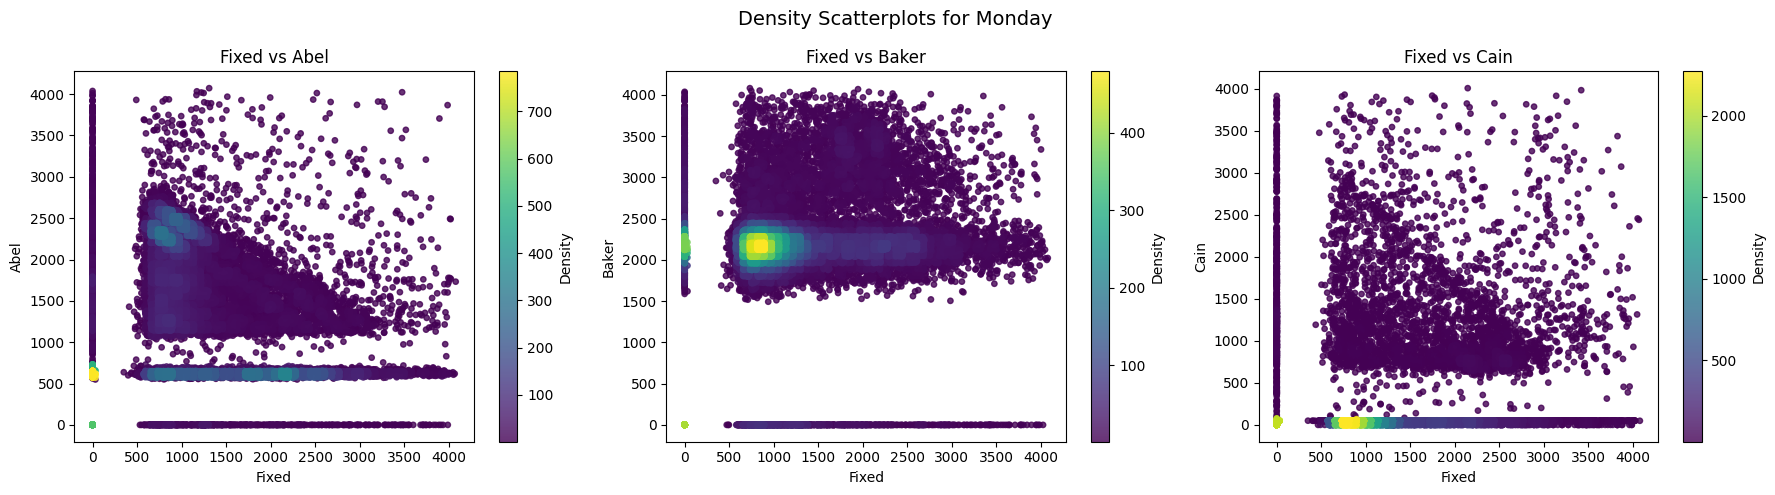

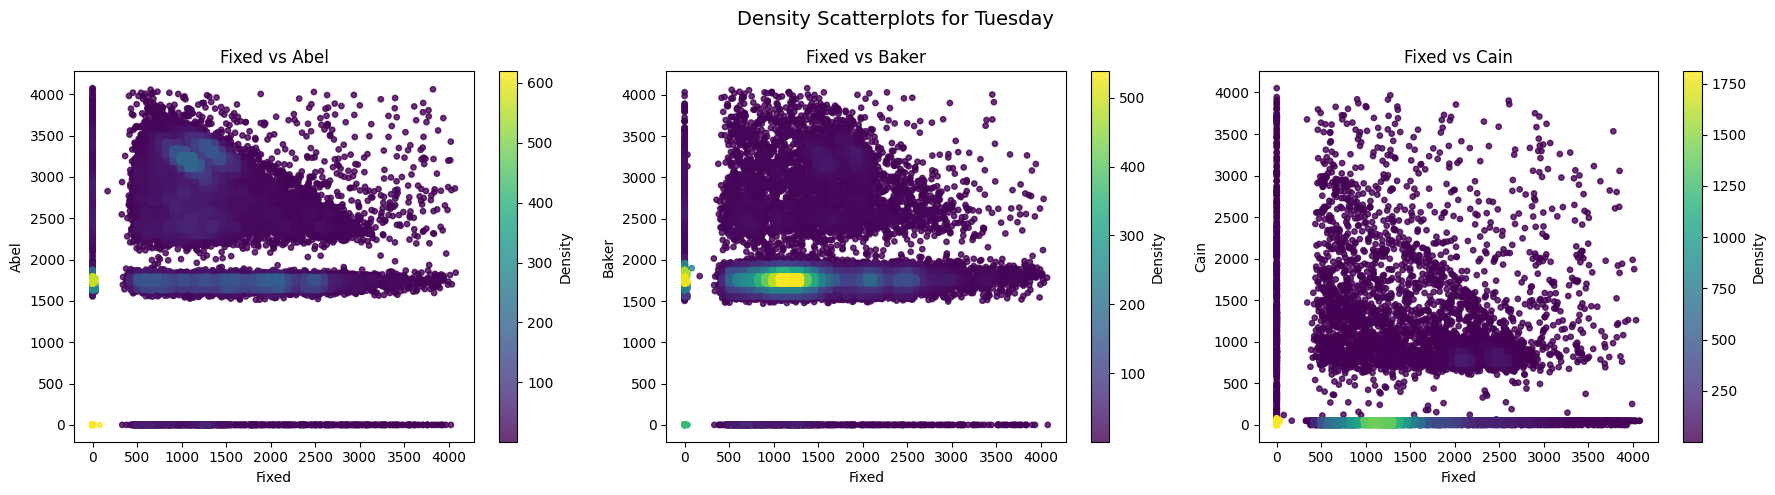

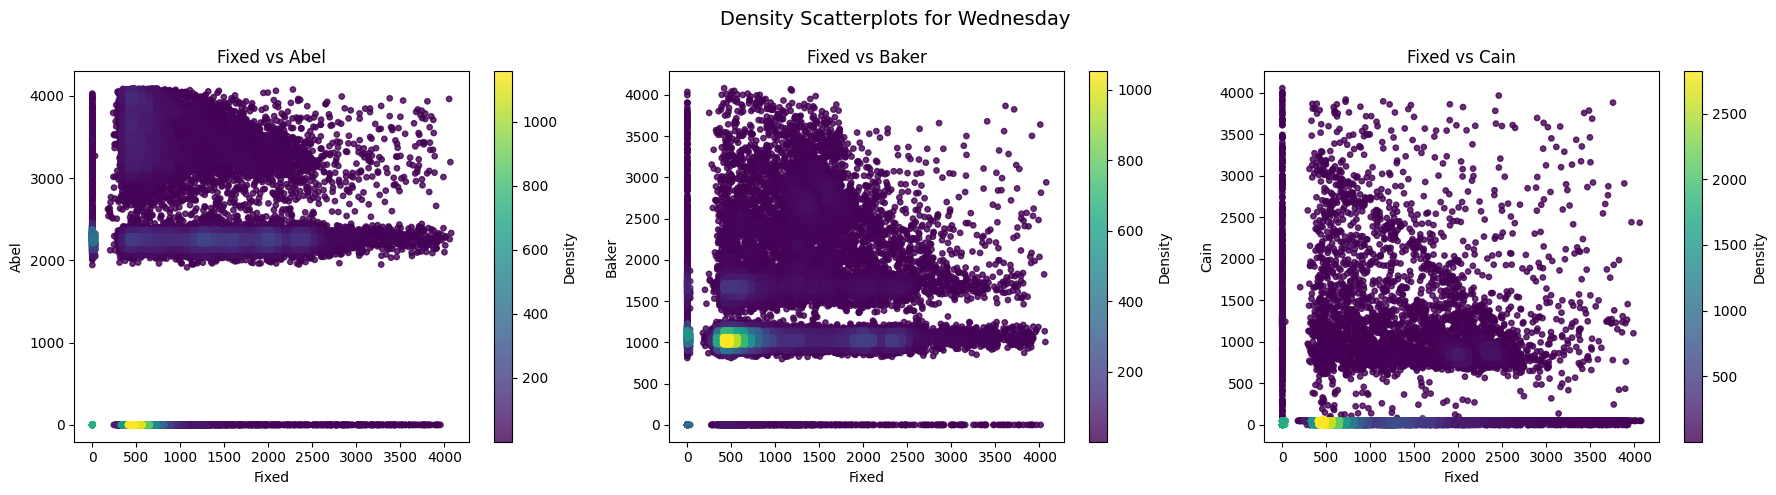

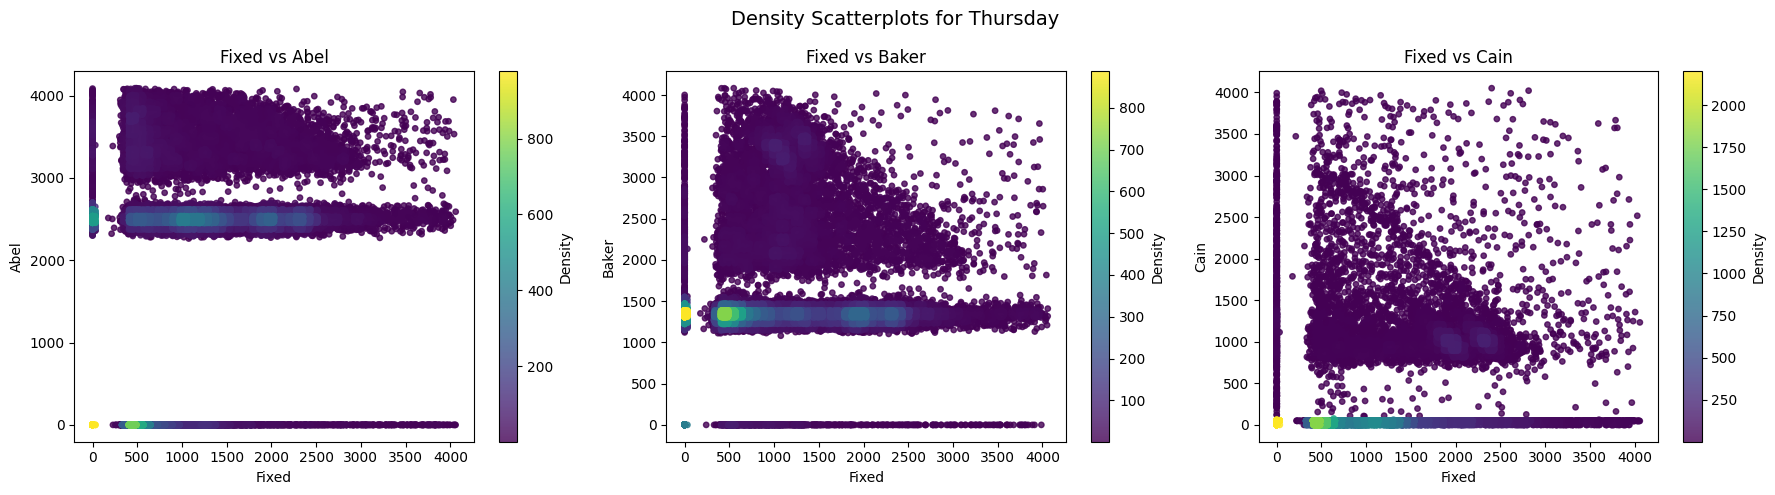

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

# List of files
files = [
    '/content/Monday_May_25_25-05-2026_13.39.20.txt',
    '/content/Tuesday_May_26_26-05-2026_14.47.37.txt',
    '/content/Wednesday_May_27_27-05-2026_13.42.28.txt',
    '/content/Thursday_May_28_28-05-2026_13.41.58.txt'
]

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday']

def plot_density_scatter(ax, x, y, title):
    # Fast density calculation using 2D histogram to avoid slow KDE on 30k+ points
    x = np.array(x)
    y = np.array(y)

    # Calculate 2D histogram for density
    hist, xedges, yedges = np.histogram2d(x, y, bins=50)

    # Find bin for each point
    xidx = np.clip(np.digitize(x, xedges) - 1, 0, hist.shape[0] - 1)
    yidx = np.clip(np.digitize(y, yedges) - 1, 0, hist.shape[1] - 1)

    # Get density for each point
    z = hist[xidx, yidx]

    # Sort points by density so dense points are plotted on top
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    # Plot with color mapped to density (z)
    sc = ax.scatter(x, y, c=z, s=15, cmap='viridis', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Fixed')
    ax.set_ylabel(title.split(' ')[-1])
    return sc

for file, day in zip(files, days):
    try:
        # Read the file. Assuming it's a comma or whitespace separated file.
        df = pd.read_csv(file, sep=None, engine='python')

        # Standardize column names
        df.columns = df.columns.str.lower()

        if 'fixed' in df.columns and all(col in df.columns for col in ['abel', 'baker', 'cain']):
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            fig.suptitle(f'Density Scatterplots for {day}', fontsize=14)

            # Drop NaNs just in case to ensure equal lengths
            df_clean = df[['fixed', 'abel', 'baker', 'cain']].dropna()

            sc1 = plot_density_scatter(axes[0], df_clean['fixed'], df_clean['abel'], 'Fixed vs Abel')
            sc2 = plot_density_scatter(axes[1], df_clean['fixed'], df_clean['baker'], 'Fixed vs Baker')
            sc3 = plot_density_scatter(axes[2], df_clean['fixed'], df_clean['cain'], 'Fixed vs Cain')

            # Add colorbars for reference
            fig.colorbar(sc1, ax=axes[0], label='Density')
            fig.colorbar(sc2, ax=axes[1], label='Density')
            fig.colorbar(sc3, ax=axes[2], label='Density')

            plt.tight_layout()
            plt.show()
        else:
            print(f"File {file} does not contain required columns. Found: {list(df.columns)}")
    except Exception as e:
        print(f"Could not process file {file}: {e}")

Processing element: Ba


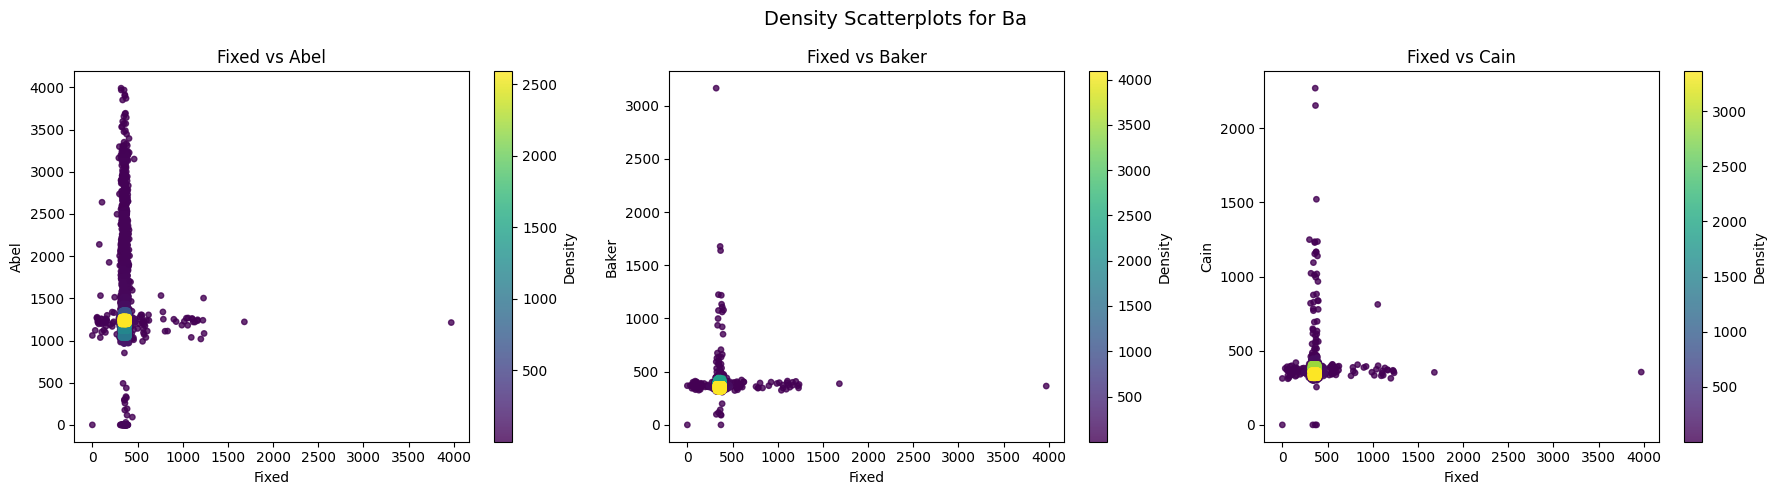

Processing element: Co


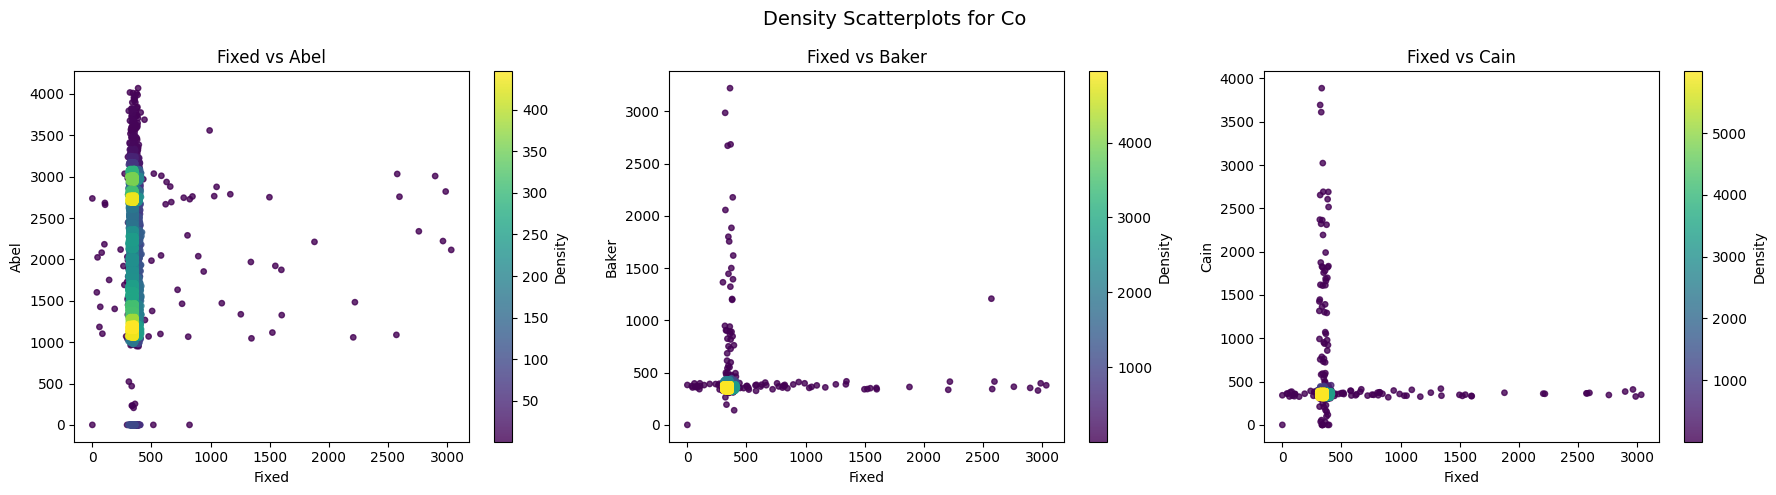

Processing element: Cs


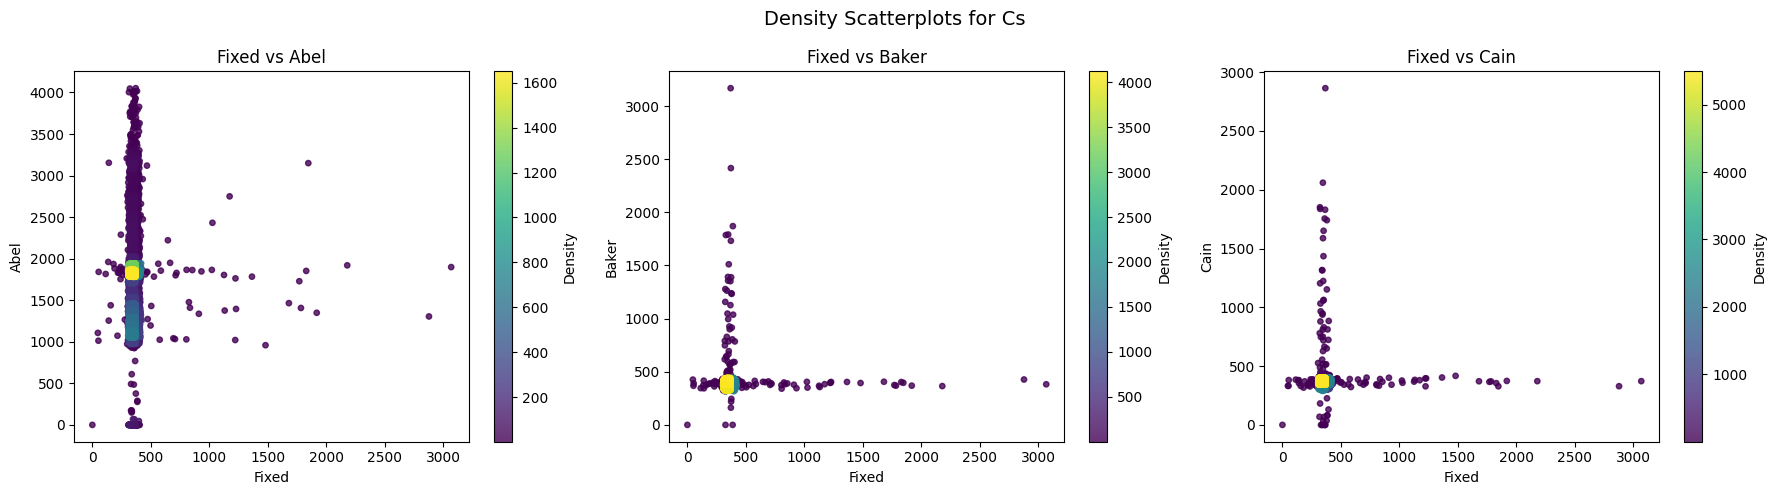

Processing element: Na


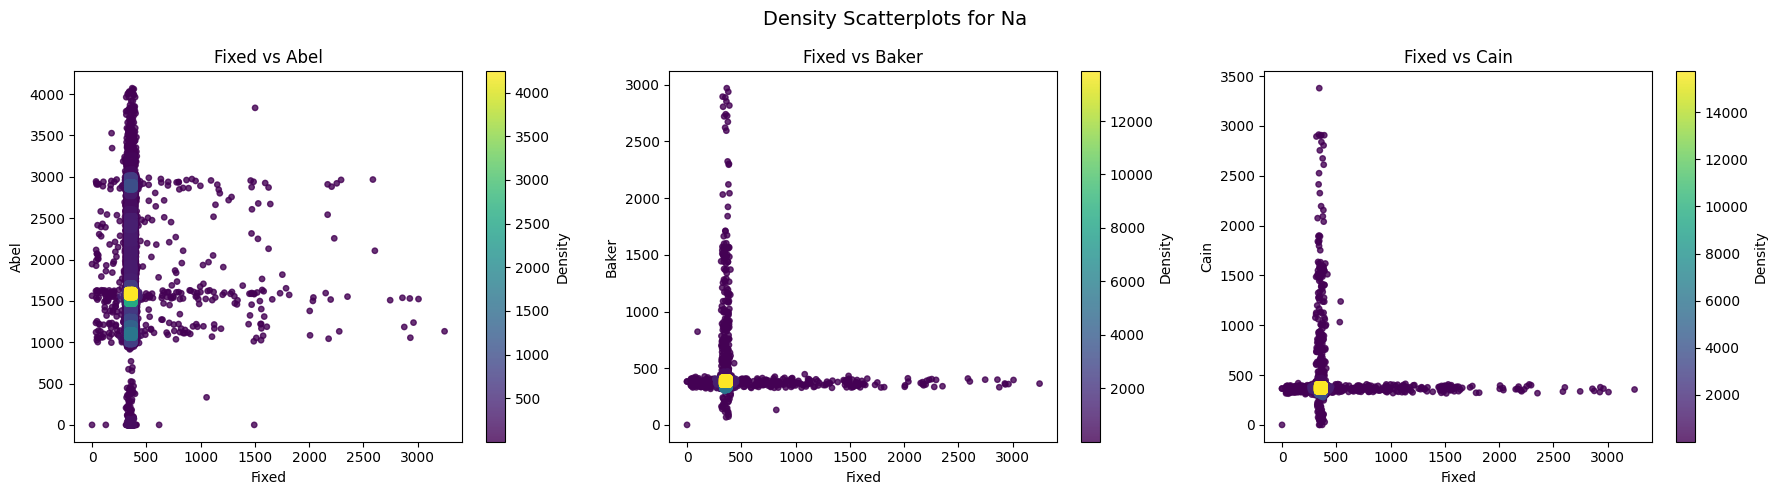

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

elements = ['Ba', 'Co', 'Cs', 'Na']

for element in elements:
    print(f"Processing element: {element}")
    try:
        # Find files for this element
        fixed_file = glob.glob(f'/content/{element}_Fixed_*.txt')
        abel_file = glob.glob(f'/content/{element}_Abel_*.txt')
        baker_file = glob.glob(f'/content/{element}_Baker_*.txt')
        cain_file = glob.glob(f'/content/{element}_Cain_*.txt')

        if not fixed_file:
            print(f"  -> Missing Fixed file for {element}. Skipping.")
            continue

        # Read the fixed file assuming the data is in the first column
        fixed_df = pd.read_csv(fixed_file[0], sep=None, engine='python')

        # Combine into a single dataframe based on row index
        df = pd.DataFrame()
        df['fixed'] = fixed_df.iloc[:, 0] # Assuming first column has the data

        # Map the other files
        file_mappings = [('abel', abel_file), ('baker', baker_file), ('cain', cain_file)]
        for name, f_list in file_mappings:
            if f_list:
                temp_df = pd.read_csv(f_list[0], sep=None, engine='python')
                df[name] = temp_df.iloc[:, 0]
            else:
                print(f"  -> Missing {name} file for {element}.")

        # Drop any rows with missing data across the matched columns
        df_clean = df.dropna()

        if len(df_clean) == 0:
            print(f"  -> No overlapping data found for {element}. Skipping.")
            continue

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Density Scatterplots for {element}', fontsize=14)

        if 'abel' in df_clean.columns:
            sc1 = plot_density_scatter(axes[0], df_clean['fixed'], df_clean['abel'], 'Fixed vs Abel')
            fig.colorbar(sc1, ax=axes[0], label='Density')
        if 'baker' in df_clean.columns:
            sc2 = plot_density_scatter(axes[1], df_clean['fixed'], df_clean['baker'], 'Fixed vs Baker')
            fig.colorbar(sc2, ax=axes[1], label='Density')
        if 'cain' in df_clean.columns:
            sc3 = plot_density_scatter(axes[2], df_clean['fixed'], df_clean['cain'], 'Fixed vs Cain')
            fig.colorbar(sc3, ax=axes[2], label='Density')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not process {element}: {e}")

### Step 1: Visualize the Energy Spectra (Histograms)
Before fitting Gaussians, we need to view the spectra to identify the ADC channel peaks for each element and detector.

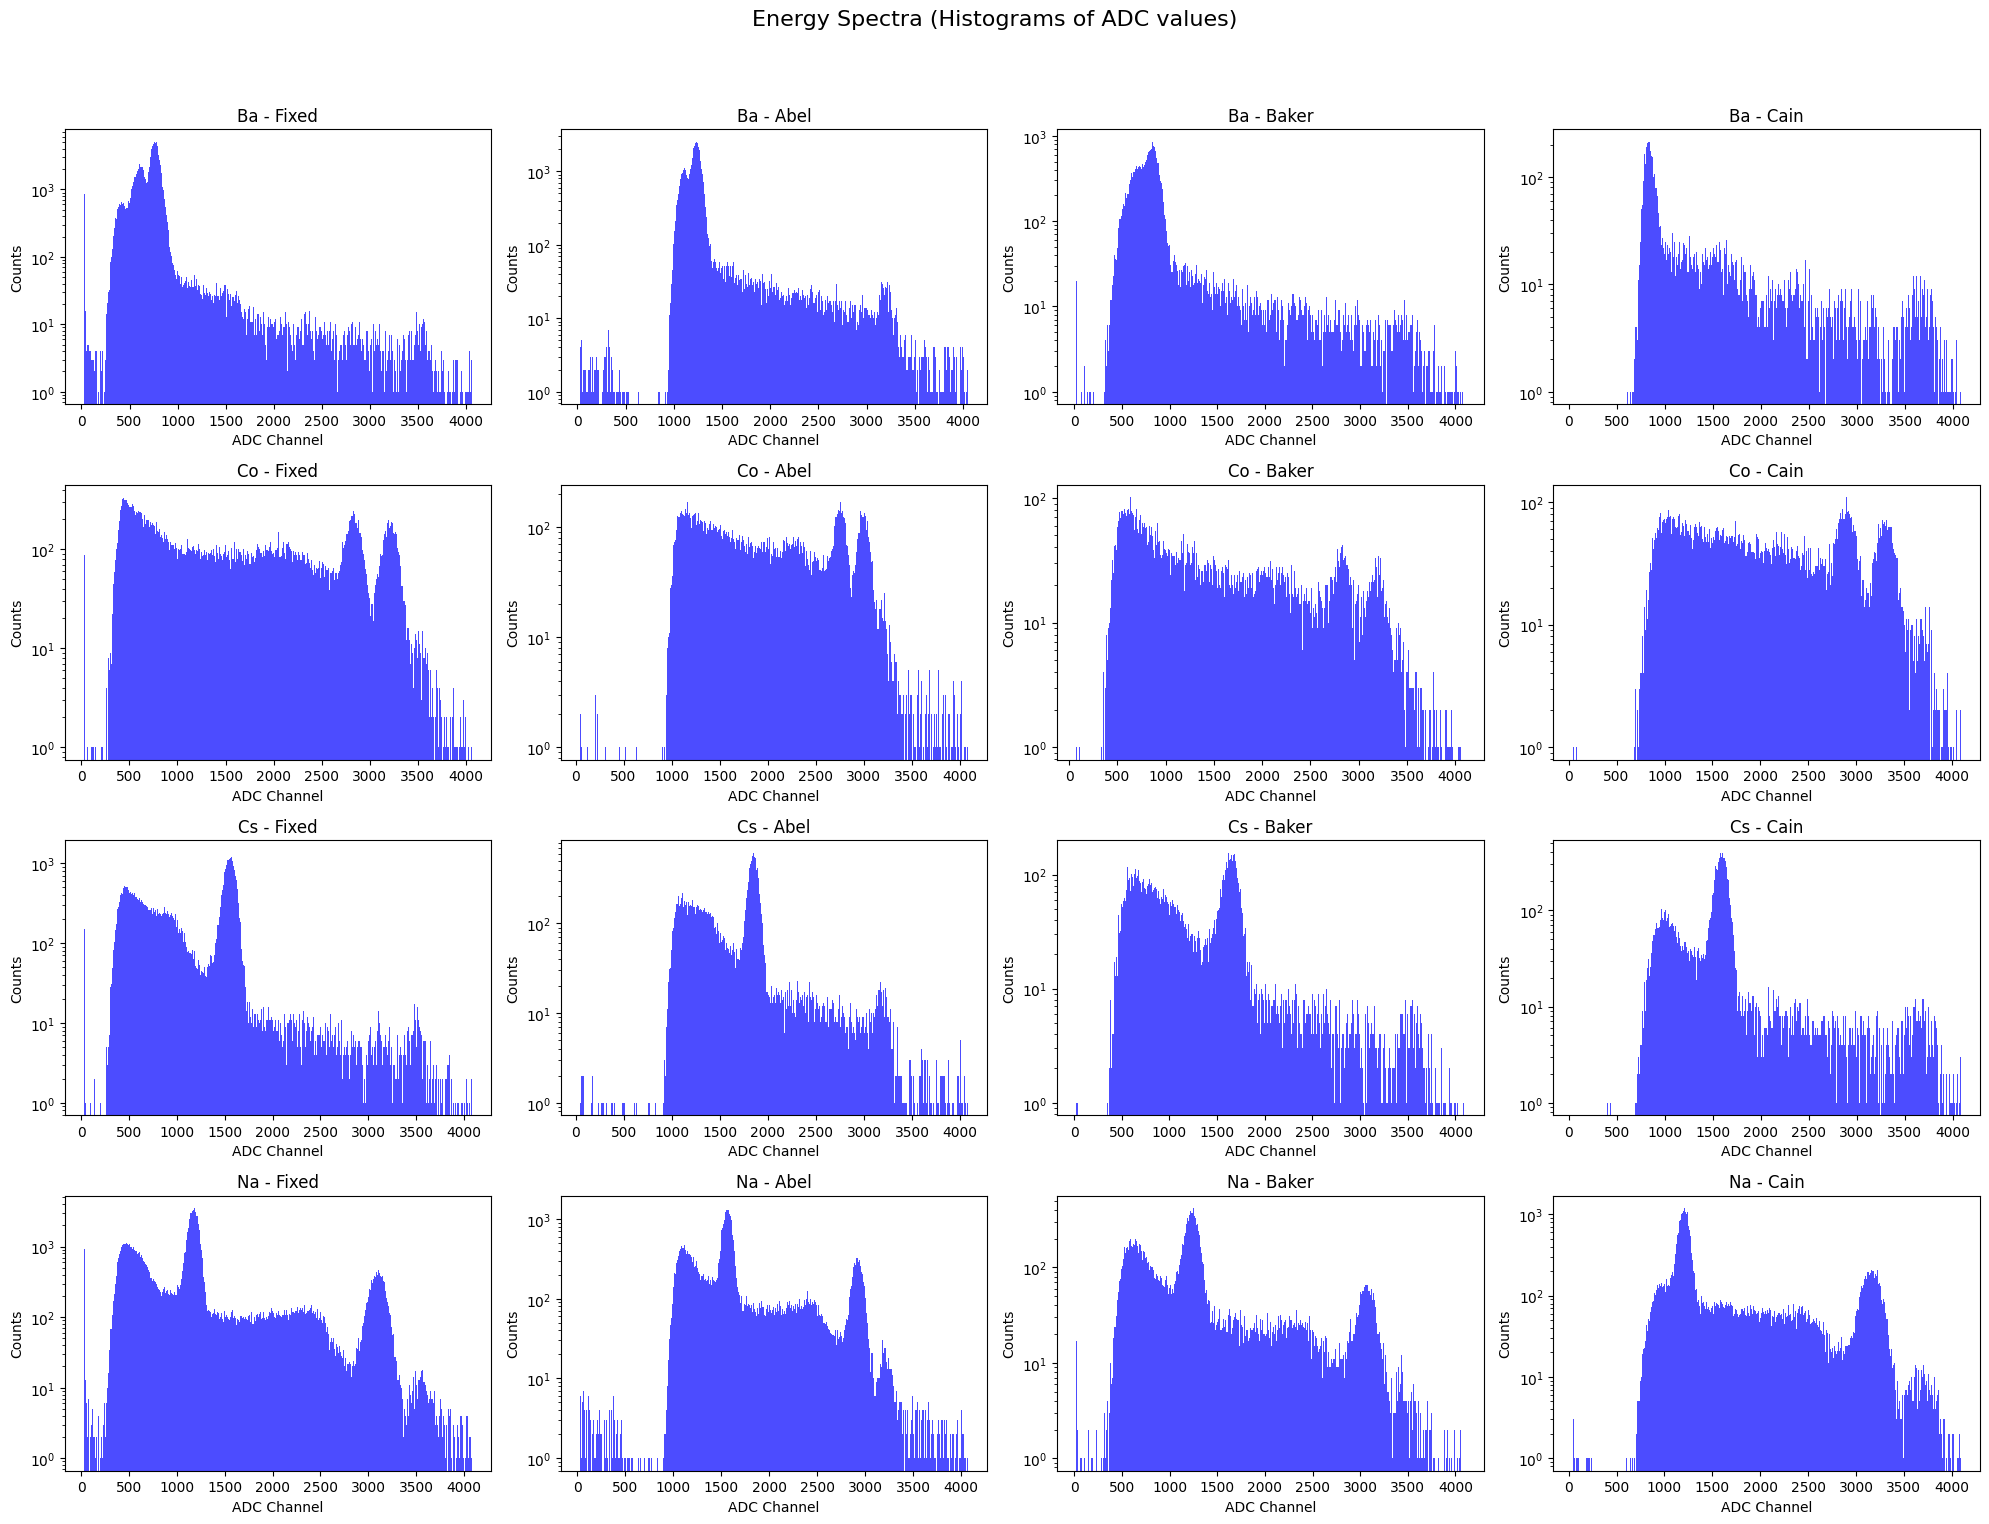

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import numpy as np

elements = ['Ba', 'Co', 'Cs', 'Na']
detectors = ['Fixed', 'Abel', 'Baker', 'Cain']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('Energy Spectra (Histograms of ADC values)', fontsize=16)

for i, element in enumerate(elements):
    for j, detector in enumerate(detectors):
        ax = axes[i, j]
        file_path = glob.glob(f'/content/{element}_{detector}_*.txt')

        if file_path:
            # Read the data
            df = pd.read_csv(file_path[0], sep=None, engine='python')

            # Find the column corresponding to the current detector
            col_name = [c for c in df.columns if detector.lower() in c.lower()]

            if col_name:
                data = df[col_name[0]].dropna()
                # Filter out 0s which are typically pedestal/underflow in MCA data
                data = data[data > 0]

                # Plot histogram
                ax.hist(data, bins=500, alpha=0.7, color='blue')
                ax.set_title(f'{element} - {detector}')
                ax.set_xlabel('ADC Channel')
                ax.set_ylabel('Counts')
                ax.set_yscale('log') # Log scale helps see both high and low energy peaks
            else:
                ax.set_title(f'{element} - {detector} (Col Not Found)')
                ax.axis('off')
        else:
            ax.set_title(f'{element} - {detector} (Missing)')
            ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Step 2: Gaussian Fitting of the Primary Peaks
This code isolates the most prominent peak for each dataset (ignoring low ADC values which are usually noise/pedestal), slices the data to only fit the region around that peak, and uses `scipy.optimize.curve_fit` to extract the ADC mean and uncertainty.

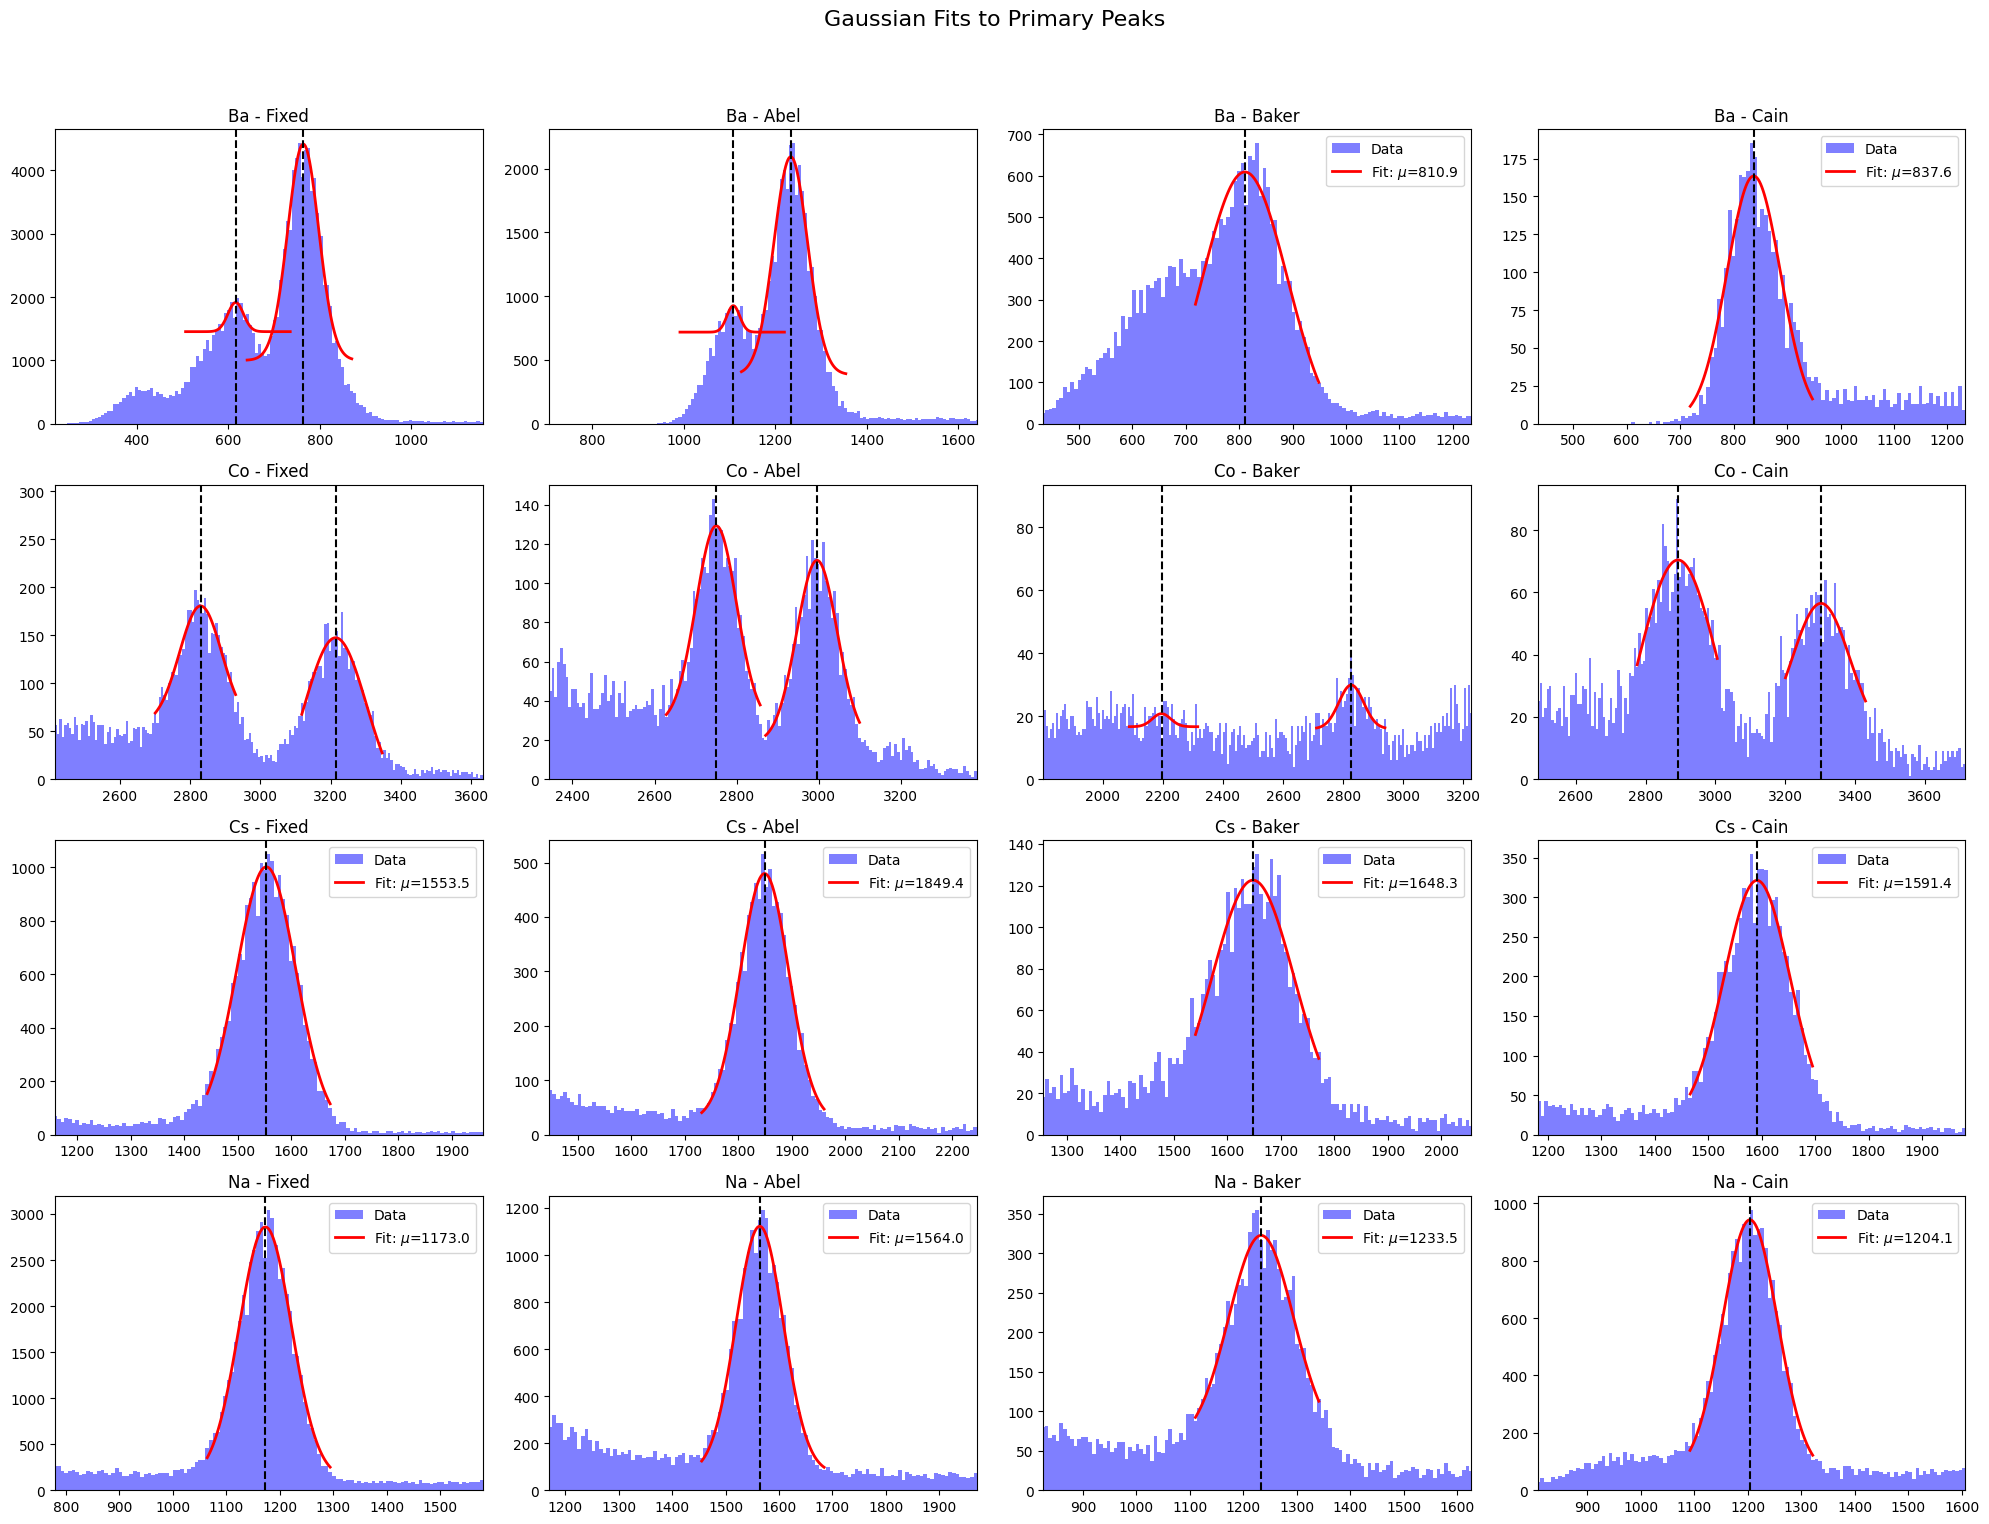


--- Fitted ADC Peak Positions ---


,Element,Detector,ADC_Peak_Mean,Uncertainty
0,Ba-303,Fixed,616.319323,14.846644
1,Ba-356,Fixed,763.939231,1.406938
2,Ba-303,Abel,1108.099478,24.479212
3,Ba-356,Abel,1233.614822,1.773473
4,Ba,Baker,810.891188,2.175690
5,Ba,Cain,837.634706,1.979519
6,Co-1173,Fixed,2830.012573,2.220757
7,Co-1332,Fixed,3214.147869,2.368085
8,Co-1173,Abel,2750.489817,1.681171
9,Co-1332,Abel,2996.027893,1.913023


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# Define the Gaussian function with a constant background
def gaussian(x, A, mu, sigma, B):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + B

elements = ['Ba', 'Co', 'Cs', 'Na']
detectors = ['Fixed', 'Abel', 'Baker', 'Cain']

results = []

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('Gaussian Fits to Primary Peaks', fontsize=16)

for i, element in enumerate(elements):
    for j, detector in enumerate(detectors):
        ax = axes[i, j]
        file_path = glob.glob(f'/content/{element}_{detector}_*.txt')

        if file_path:
            df = pd.read_csv(file_path[0], sep=None, engine='python')

            # Extract the specific column for this detector
            col_name = [c for c in df.columns if detector.lower() in c.lower()]
            if not col_name:
                ax.set_title(f'{element} - {detector} (Col missing)')
                ax.axis('off')
                continue

            data = df[col_name[0]].dropna()
            data = data[data > 0]

            # Create histogram
            counts, bin_edges = np.histogram(data, bins=600)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

            # Ignore extreme low channels (pedestal/noise)
            min_channel = 1500 if element == 'Co' else 10
            valid_idx = bin_centers > min_channel

            if not np.any(valid_idx):
                ax.set_title(f'{element} - {detector} (No valid data)')
                ax.axis('off')
                continue

            valid_counts = counts[valid_idx]
            valid_centers = bin_centers[valid_idx]

            if len(valid_counts) == 0 or max(valid_counts) == 0:
                 continue

            # Use find_peaks to locate actual local maxima
            peaks, _ = find_peaks(valid_counts, prominence=5, distance=15, width=3)

            peaks_to_fit = []
            if len(peaks) > 0:
                if element == 'Co':
                    # Find the top 2 peaks for Cobalt
                    sorted_peaks = peaks[np.argsort(valid_counts[peaks])][::-1]
                    best_peaks = np.sort(sorted_peaks[:2]) if len(sorted_peaks) >= 2 else sorted_peaks
                    if len(best_peaks) == 2:
                        peaks_to_fit = [('Co-1173', best_peaks[0]), ('Co-1332', best_peaks[1])]
                    else:
                        peaks_to_fit = [('Co-1332', best_peaks[0])] # Fallback
                elif element == 'Ba' and detector in ['Fixed', 'Abel']:
                    # Find the top 2 peaks for Barium in Fixed and Abel
                    sorted_peaks = peaks[np.argsort(valid_counts[peaks])][::-1]
                    best_peaks = np.sort(sorted_peaks[:2]) if len(sorted_peaks) >= 2 else sorted_peaks
                    if len(best_peaks) == 2:
                        peaks_to_fit = [('Ba-303', best_peaks[0]), ('Ba-356', best_peaks[1])]
                    else:
                        peaks_to_fit = [('Ba', best_peaks[0])]
                else:
                    # For others, just pick the highest peak
                    best_peak_idx = peaks[np.argmax(valid_counts[peaks])]
                    peaks_to_fit = [(element, best_peak_idx)]
            else:
                # Fallback if no peaks found by the algorithm
                max_idx = np.argmax(valid_counts)
                peaks_to_fit = [(element, max_idx)]

            ax.hist(data, bins=600, alpha=0.5, color='blue', label='Data' if len(peaks_to_fit)==1 else None)
            plot_xlims = []

            for peak_name, p_idx in peaks_to_fit:
                mu_guess = valid_centers[p_idx]
                amp_guess = valid_counts[p_idx]

                # Define a region around the peak to fit (+/- 120 ADC channels)
                window_size = 120
                fit_mask = (bin_centers > mu_guess - window_size) & (bin_centers < mu_guess + window_size)

                x_fit = bin_centers[fit_mask]
                y_fit = counts[fit_mask]

                try:
                    # Fit the Gaussian
                    p0 = [amp_guess, mu_guess, 20, np.min(y_fit)]
                    popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=p0)

                    mu = popt[1]
                    mu_unc = np.sqrt(pcov[1, 1])

                    results.append({
                        'Element': peak_name,
                        'Detector': detector,
                        'ADC_Peak_Mean': mu,
                        'Uncertainty': mu_unc
                    })

                    # Plot the fitted curve over the isolated region
                    x_plot = np.linspace(x_fit.min(), x_fit.max(), 100)
                    ax.plot(x_plot, gaussian(x_plot, *popt), color='red', linewidth=2, label=rf'Fit: $\mu$={mu:.1f}' if len(peaks_to_fit)==1 else None)
                    ax.axvline(mu, color='black', linestyle='--')
                    plot_xlims.extend([mu_guess - 400, mu_guess + 400])

                except Exception as e:
                    pass

            ax.set_title(f'{element} - {detector}')
            if plot_xlims:
                ax.set_xlim(max(0, min(plot_xlims)), min(bin_centers.max(), max(plot_xlims)))
            if len(peaks_to_fit) == 1:
                ax.legend()

        else:
            ax.set_title(f'{element} - {detector} (Missing)')
            ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Display the results as a dataframe
print("\n--- Fitted ADC Peak Positions ---")
fit_results_df = pd.DataFrame(results)
display(fit_results_df)


### Step 3: Linear Energy Calibration
Map the extracted ADC peak positions to known theoretical energies and perform a linear fit ($Energy = m \cdot ADC + c$) to find the calibration constants for each detector.

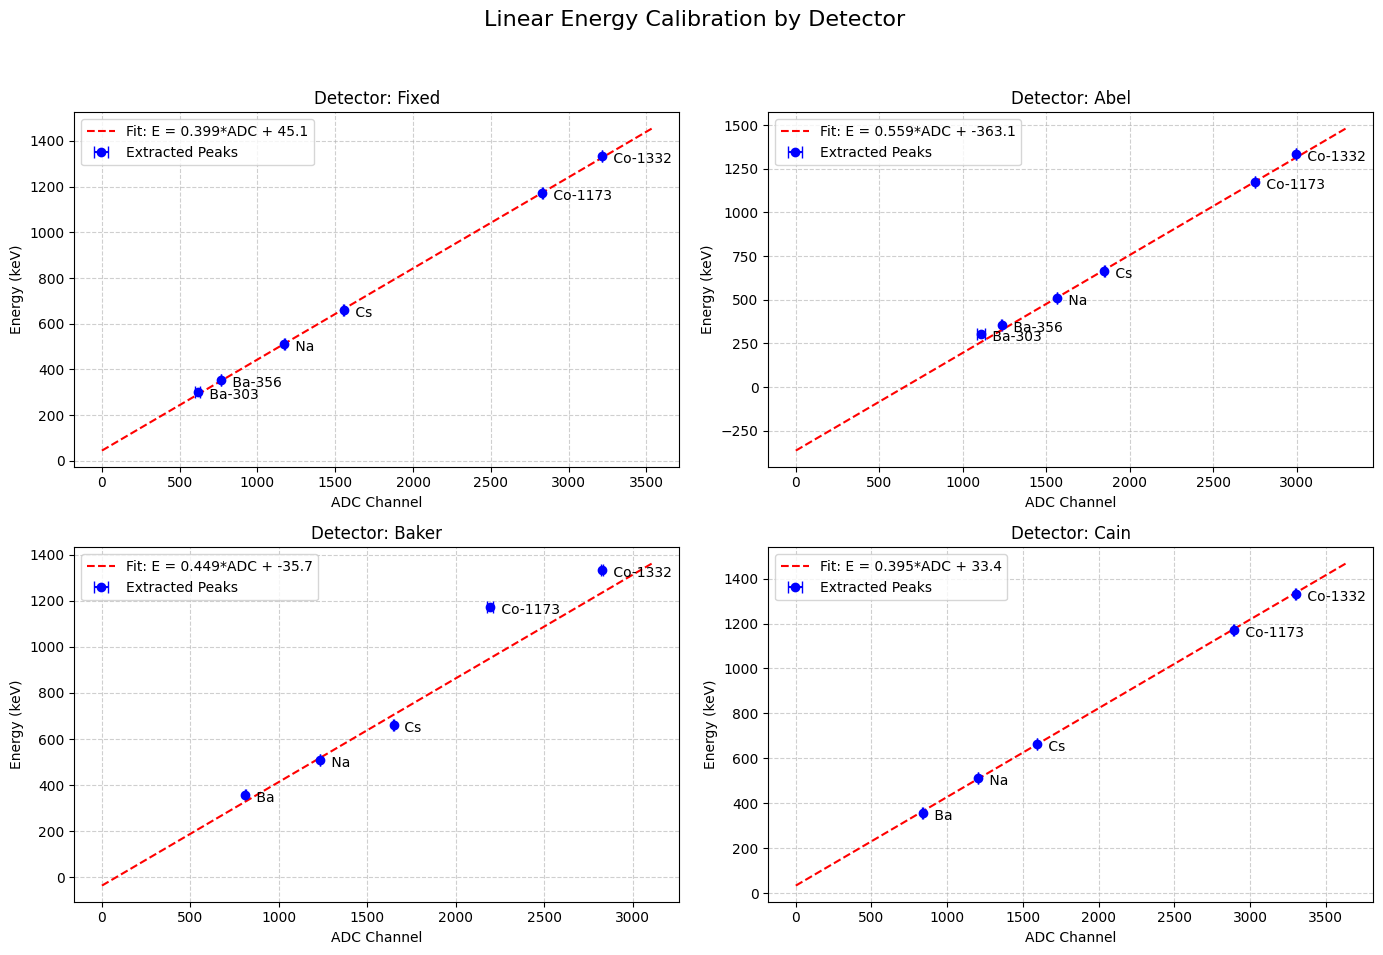


--- Calibration Fit Results ---


,Detector,Slope (keV/ch),Slope Unc,Intercept (keV),Intercept Unc
0,Fixed,0.398638,0.000350,45.141623,0.557624
1,Abel,0.559359,0.000586,-363.091669,1.131939
2,Baker,0.449358,0.001383,-35.650472,1.868894
3,Cain,0.394778,0.000568,33.420942,0.826442


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# 1. Define known theoretical energies in keV
theoretical_energies = {
    'Ba': 356.0,       # 133Ba primary peak
    'Ba-356': 356.0,   # 133Ba primary peak when multiple are fitted
    'Ba-303': 302.9,   # 133Ba secondary peak (302.9 keV)
    'Na': 511.0,       # 22Na annihilation peak
    'Cs': 662.0,       # 137Cs primary peak
    'Co': 1332.5,      # Fallback if only 1 Co peak found
    'Co-1173': 1173.2, # 60Co lower primary peak
    'Co-1332': 1332.5  # 60Co upper primary peak
}

# Map energies to our results dataframe
fit_results_df['True_Energy_keV'] = fit_results_df['Element'].map(theoretical_energies)

# 2. Define the linear calibration function
def linear_calibration(x, m, c):
    return m * x + c

detectors = ['Fixed', 'Abel', 'Baker', 'Cain']
calibration_results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linear Energy Calibration by Detector', fontsize=16)
axes = axes.flatten()

for i, detector in enumerate(detectors):
    ax = axes[i]

    # Filter data for the current detector
    det_data = fit_results_df[fit_results_df['Detector'] == detector].dropna()

    if len(det_data) < 2:
        ax.set_title(f'{detector} (Insufficient Data)')
        ax.axis('off')
        continue

    x_data = det_data['ADC_Peak_Mean'].values
    x_err = det_data['Uncertainty'].values
    y_data = det_data['True_Energy_keV'].values
    elements_labels = det_data['Element'].values

    # Sort data by ADC channel for a clean line plot
    sort_idx = np.argsort(x_data)
    x_data, x_err, y_data, elements_labels = x_data[sort_idx], x_err[sort_idx], y_data[sort_idx], elements_labels[sort_idx]

    try:
        # Since curve_fit expects y-uncertainties by default, we approximate the effective y-uncertainty
        # to properly weight the fit based on our x-uncertainties.
        # Initial unweighted fit to get rough slope:
        popt_rough, _ = curve_fit(linear_calibration, x_data, y_data)
        effective_y_err = np.abs(popt_rough[0]) * x_err

        # Final weighted fit
        popt, pcov = curve_fit(linear_calibration, x_data, y_data, sigma=effective_y_err, absolute_sigma=True)
        m, c = popt
        m_unc, c_unc = np.sqrt(np.diag(pcov))

        calibration_results.append({
            'Detector': detector,
            'Slope (keV/ch)': m,
            'Slope Unc': m_unc,
            'Intercept (keV)': c,
            'Intercept Unc': c_unc
        })

        # Plotting
        ax.errorbar(x_data, y_data, xerr=x_err, fmt='o', color='blue', label='Extracted Peaks', markersize=6, capsize=4)

        # Add element labels to points
        for x, y, el in zip(x_data, y_data, elements_labels):
            ax.annotate(f' {el}', (x, y), textcoords="offset points", xytext=(5, -5), ha='left')

        # Plot fit line
        x_line = np.linspace(0, max(x_data) * 1.1, 100)
        ax.plot(x_line, linear_calibration(x_line, *popt), 'r--', label=f'Fit: E = {m:.3f}*ADC + {c:.1f}')

        ax.set_title(f'Detector: {detector}')
        ax.set_xlabel('ADC Channel')
        ax.set_ylabel('Energy (keV)')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()

    except Exception as e:
        ax.set_title(f'{detector} (Fit Failed)')
        print(f"Fit failed for {detector}: {e}")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Calibration Fit Results ---")
calibration_df = pd.DataFrame(calibration_results)
display(calibration_df)


### Step 4: Residuals Analysis
Plotting the residuals (True Energy - Fitted Energy) helps isolate exactly which element peaks were misidentified during the Gaussian fitting step. Large residuals indicate a peak that is pulling the linear fit off its ideal path.

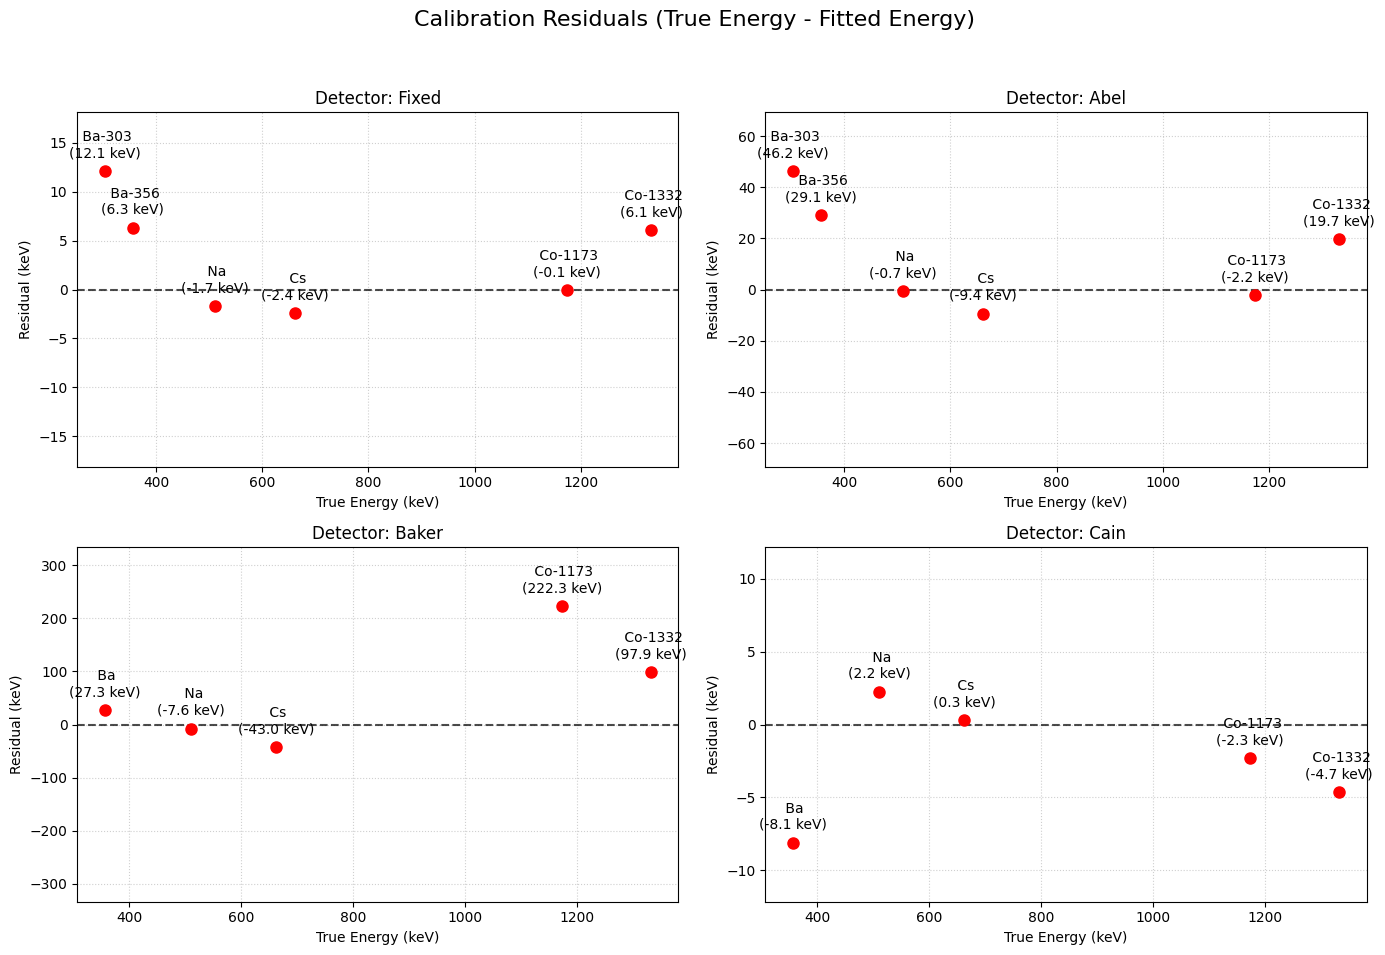

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Calibration Residuals (True Energy - Fitted Energy)', fontsize=16)
axes = axes.flatten()

for i, detector in enumerate(detectors):
    ax = axes[i]

    # Get calibration constants for this detector
    det_calib = calibration_df[calibration_df['Detector'] == detector]
    if det_calib.empty:
        ax.set_title(f'{detector} (No Calibration Data)')
        ax.axis('off')
        continue

    m = det_calib['Slope (keV/ch)'].values[0]
    c = det_calib['Intercept (keV)'].values[0]

    # Get peak data
    det_data = fit_results_df[fit_results_df['Detector'] == detector]
    if det_data.empty:
        continue

    adc = det_data['ADC_Peak_Mean'].values
    true_e = det_data['True_Energy_keV'].values
    elements_labels = det_data['Element'].values

    # Calculate expected energy based on the linear fit and find the residual
    fit_e = m * adc + c
    residuals = true_e - fit_e

    # Plotting
    ax.axhline(0, color='black', linestyle='--', alpha=0.7)
    ax.plot(true_e, residuals, 'o', markersize=8, color='red')

    # Annotate points with element name and residual value
    for e_val, res, el in zip(true_e, residuals, elements_labels):
        ax.annotate(f' {el}\n({res:.1f} keV)', (e_val, res),
                    textcoords="offset points", xytext=(0, 10), ha='center')

    ax.set_title(f'Detector: {detector}')
    ax.set_xlabel('True Energy (keV)')
    ax.set_ylabel('Residual (keV)')
    ax.grid(True, linestyle=':', alpha=0.6)

    # Symmetrical y-axis for better visual representation of error magnitude
    y_max = max(abs(residuals)) * 1.5 if len(residuals) > 0 else 10
    ax.set_ylim(-y_max, y_max)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


--- Abel Quadratic Calibration Results ---
a (quadratic coeff): 5.548345e-05 ± 3.999143e-06
b (linear coeff):    0.3180 ± 0.0166
c (intercept):       -119.21 ± 15.38


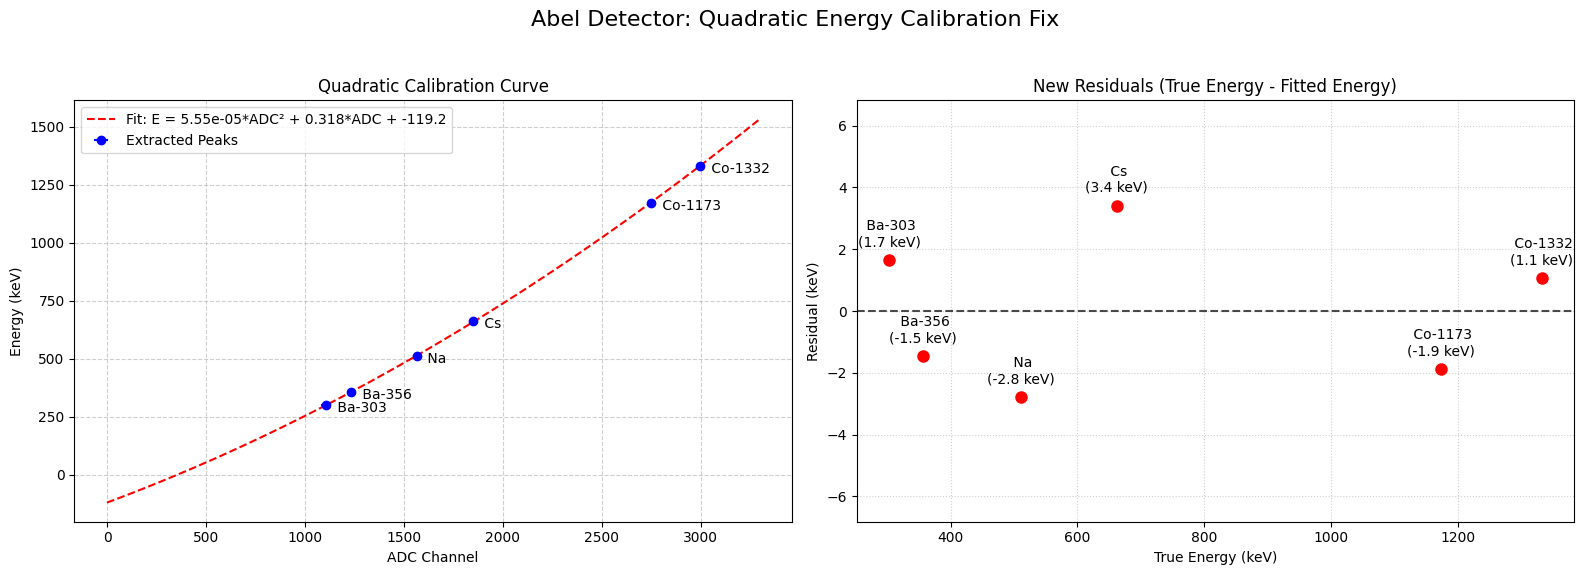

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# Define the quadratic calibration function
def quadratic_calibration(x, a, b, c):
    return a * x**2 + b * x + c

# Extract Abel's data
abel_data = fit_results_df[fit_results_df['Detector'] == 'Abel'].dropna()
x_data = abel_data['ADC_Peak_Mean'].values
y_data = abel_data['True_Energy_keV'].values
x_err = abel_data['Uncertainty'].values
elements_labels = abel_data['Element'].values

# Sort the data by ADC channel for a clean line plot
sort_idx = np.argsort(x_data)
x_data, y_data, x_err, elements_labels = x_data[sort_idx], y_data[sort_idx], x_err[sort_idx], elements_labels[sort_idx]

# Perform the quadratic fit
popt_abel, pcov_abel = curve_fit(quadratic_calibration, x_data, y_data)
a, b, c = popt_abel
a_unc, b_unc, c_unc = np.sqrt(np.diag(pcov_abel))

print("--- Abel Quadratic Calibration Results ---")
print(f"a (quadratic coeff): {a:.6e} ± {a_unc:.6e}")
print(f"b (linear coeff):    {b:.4f} ± {b_unc:.4f}")
print(f"c (intercept):       {c:.2f} ± {c_unc:.2f}")

# Plot the result and new residuals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Abel Detector: Quadratic Energy Calibration Fix', fontsize=16)

# 1. Fit Plot
ax1.errorbar(x_data, y_data, xerr=x_err, fmt='o', color='blue', label='Extracted Peaks')
x_line = np.linspace(0, max(x_data) * 1.1, 100)
ax1.plot(x_line, quadratic_calibration(x_line, *popt_abel), 'r--',
         label=f'Fit: E = {a:.2e}*ADC² + {b:.3f}*ADC + {c:.1f}')

for x, y, el in zip(x_data, y_data, elements_labels):
    ax1.annotate(f' {el}', (x, y), textcoords="offset points", xytext=(5, -5), ha='left')

ax1.set_title('Quadratic Calibration Curve')
ax1.set_xlabel('ADC Channel')
ax1.set_ylabel('Energy (keV)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# 2. Residuals Plot
fit_e = quadratic_calibration(x_data, *popt_abel)
residuals = y_data - fit_e

ax2.axhline(0, color='black', linestyle='--', alpha=0.7)
ax2.plot(y_data, residuals, 'o', markersize=8, color='red')

for e_val, res, el in zip(y_data, residuals, elements_labels):
    ax2.annotate(f' {el}\n({res:.1f} keV)', (e_val, res), textcoords="offset points", xytext=(0, 10), ha='center')

ax2.set_title('New Residuals (True Energy - Fitted Energy)')
ax2.set_xlabel('True Energy (keV)')
ax2.set_ylabel('Residual (keV)')
# Keep the y-axis roughly symmetric for easy visual comparison
y_lim = max(abs(residuals)) * 2 if len(residuals) > 0 else 10
ax2.set_ylim(-y_lim, y_lim)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Save the quadratic parameters in a dictionary for the Compton scattering conversion step
abel_calib_params = {'a': a, 'b': b, 'c': c}


### Step 5: Convert Compton Data to True Energy
First, let's display the provided screenshot with the scattering angles, and then convert the raw ADC values in our daily coincidence files to True Energy (keV).

In [ ]:
from IPython.display import Image, display

# Display the uploaded screenshot of the scattering angles
try:
    display(Image(filename='/content/Screenshot 2026-06-02 194204.png'))
except Exception as e:
    print(f"Could not display image: {e}")

Could not display image: [Errno 2] No such file or directory: '/content/Screenshot 2026-06-02 194204.png'


In [ ]:
import pandas as pd
import numpy as np

# 1. Recreate calib_dict from the original calibration_df
calib_dict = {}
for _, row in calibration_df.iterrows():
    calib_dict[row['Detector']] = {'m': row['Slope (keV/ch)'], 'c': row['Intercept (keV)']}

# 2. List of daily Compton scattering files
compton_files = [
    ('/content/Monday_May_25_25-05-2026_13.39.20.txt', 'Monday'),
    ('/content/Tuesday_May_26_26-05-2026_14.47.37.txt', 'Tuesday'),
    ('/content/Wednesday_May_27_27-05-2026_13.42.28.txt', 'Wednesday'),
    ('/content/Thursday_May_28_28-05-2026_13.41.58.txt', 'Thursday')
]

# Dictionary to store the calibrated dataframes
calibrated_data = {}

print("Converting ADC to True Energy using linear Calibration for all detectors...")
for file, day in compton_files:
    try:
        df = pd.read_csv(file, sep=None, engine='python')
        df.columns = df.columns.str.lower()

        # Ensure all necessary columns exist
        if all(col in df.columns for col in ['fixed', 'abel', 'baker', 'cain']):
            calibrated_df = pd.DataFrame()

            # Apply linear calibration to all detectors
            for det in ['fixed', 'abel', 'baker', 'cain']:
                det_title = det.capitalize()
                m = calib_dict[det_title]['m']
                c = calib_dict[det_title]['c']
                calibrated_df[det] = df[det] * m + c

            calibrated_data[day] = calibrated_df
            print(f"Successfully calibrated data for {day}")
        else:
            print(f"Missing expected columns in {day}'s data.")
    except Exception as e:
        print(f"Error processing {day}: {e}")

# Preview Monday's calibrated data
if 'Monday' in calibrated_data:
    print("\nPreview of Calibrated Energy Data for Monday (keV):")
    display(calibrated_data['Monday'].head())


Converting ADC to True Energy using linear Calibration for all detectors...
Successfully calibrated data for Monday
Successfully calibrated data for Tuesday
Successfully calibrated data for Wednesday
Successfully calibrated data for Thursday

Preview of Calibrated Energy Data for Monday (keV):


,fixed,abel,baker,cain
0,45.141623,-363.091669,-35.650472,33.420942
1,752.324977,1143.262141,845.090301,53.554645
2,788.601011,449.097611,819.027564,53.159867
3,556.593846,29.018996,-35.650472,53.159867
4,45.141623,62.580537,-35.650472,53.159867


### Step 6: 2D Gaussian Fitting and Energy Extraction
Now we isolate the 2D coincidence peaks (Fixed Energy vs. Movable Detector Energy) for each day and use a 2D Gaussian fit on the histograms to extract the precise peak coordinates.

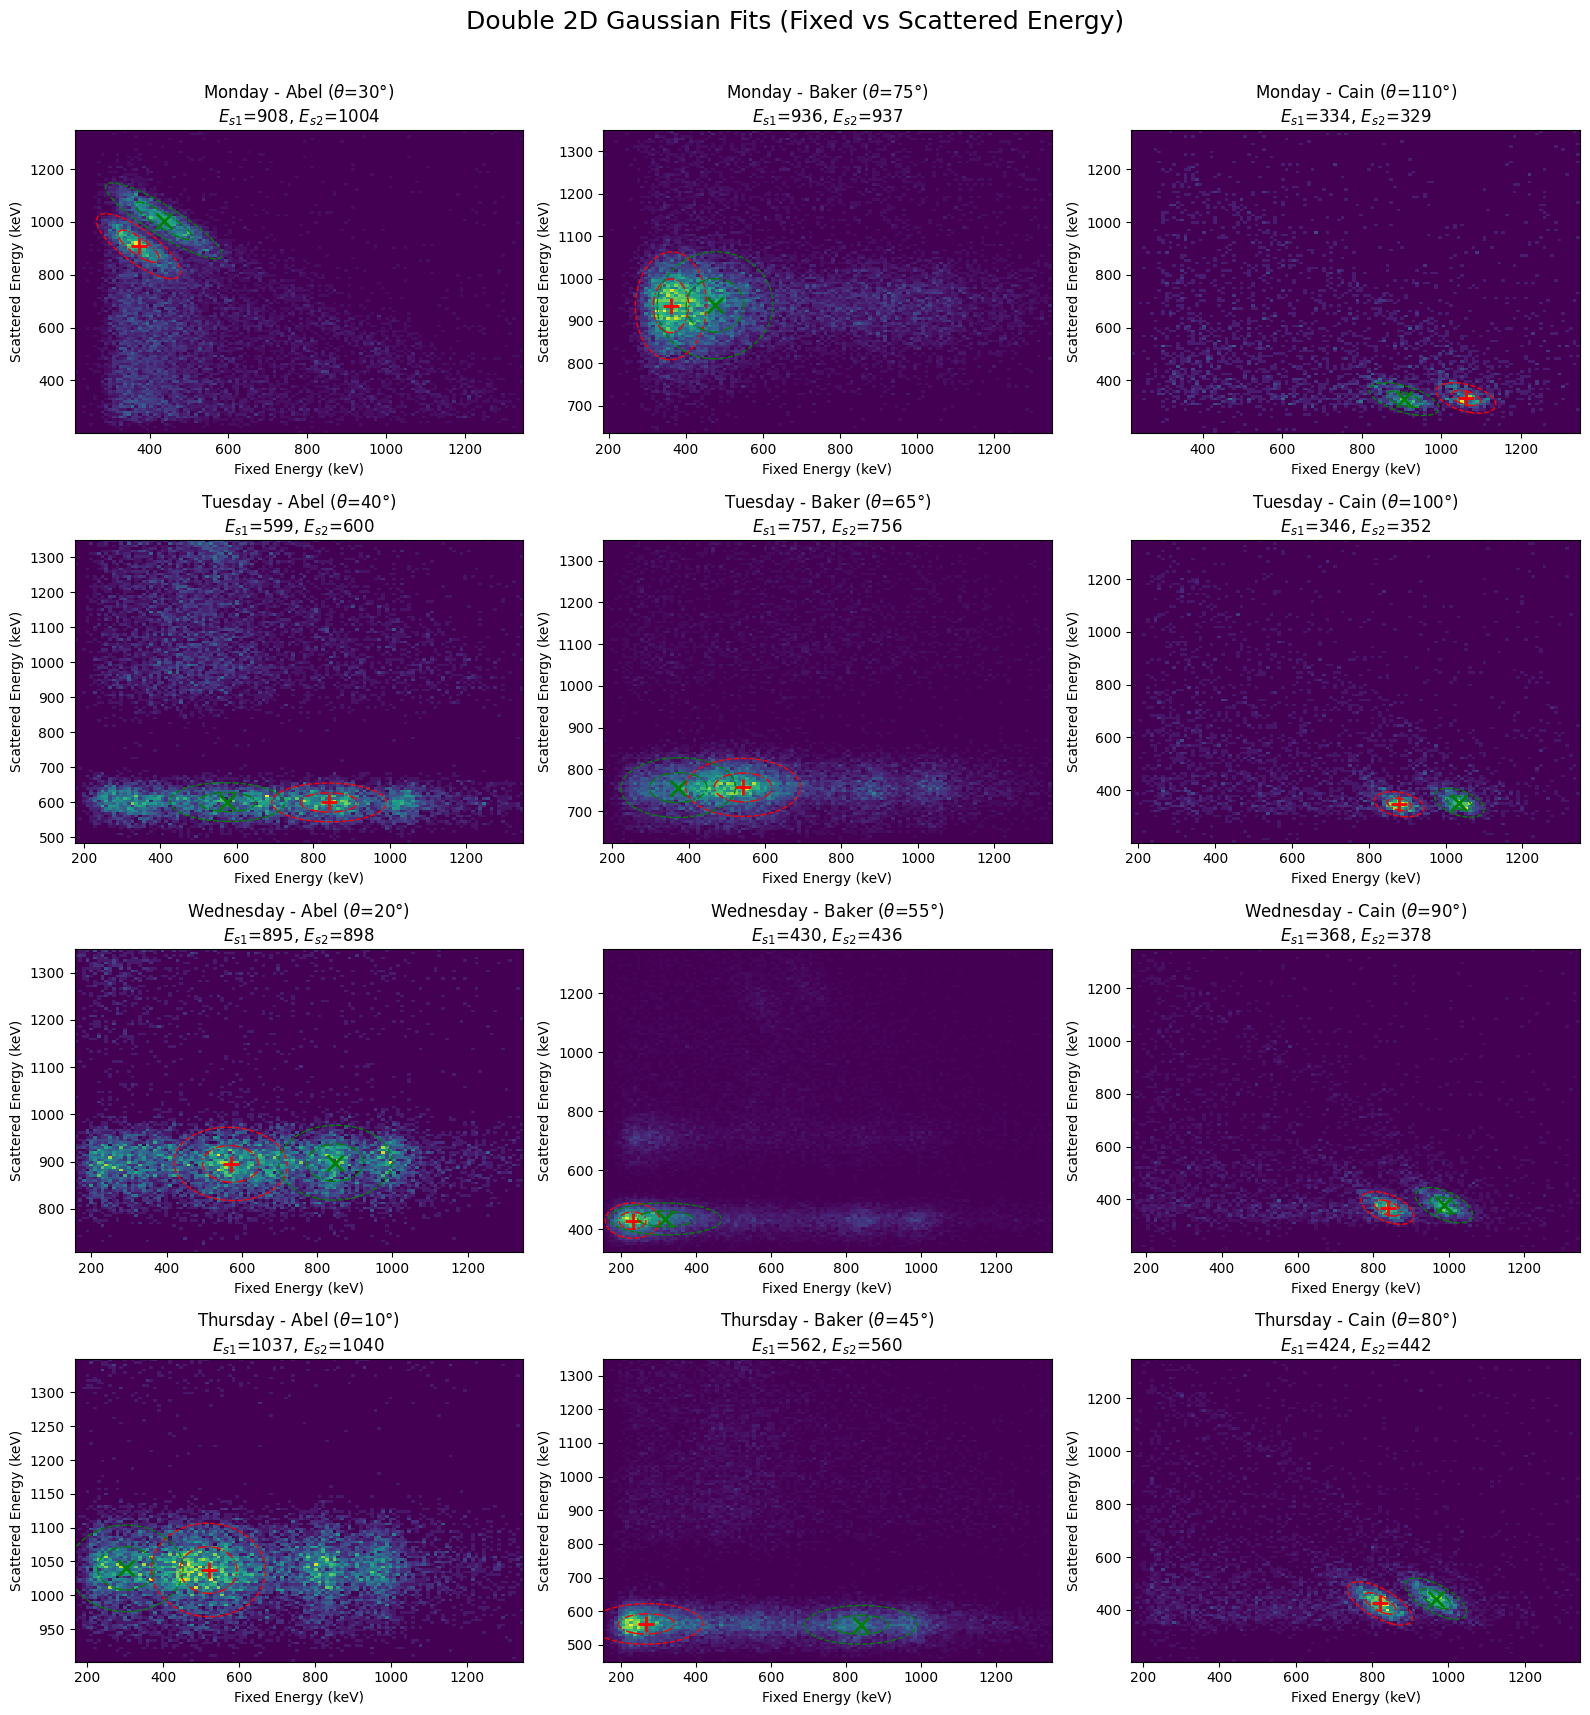


--- Extracted Coincidence Peak Energies (Double Gaussian) ---


,Day,Detector,Angle_deg,Raw_Angle_deg,Recoil_1_Fixed_keV,Scattered_1_Movable_keV,Scattered_1_Err_keV,Recoil_2_Fixed_keV,Scattered_2_Movable_keV,Scattered_2_Err_keV
0,Monday,Abel,30,120,371.636097,908.054223,0.801377,436.018603,1003.852344,0.992877
1,Monday,Baker,75,15,361.594611,935.844293,0.912185,476.102491,936.849267,0.927314
2,Monday,Cain,110,200,1062.901211,333.705839,0.585098,906.735369,329.142766,0.609370
3,Tuesday,Abel,40,130,841.799643,598.961361,0.539841,575.098798,599.990308,0.654782
4,Tuesday,Baker,65,25,542.694839,756.519490,0.350696,372.930582,756.066410,0.584782
5,Tuesday,Cain,100,190,879.470863,345.934168,0.275469,1035.890405,351.541196,0.352051
6,Wednesday,Abel,20,110,570.301462,895.096001,0.615205,847.917667,897.834765,0.739879
7,Wednesday,Baker,55,35,229.877153,429.851651,0.537249,317.360281,435.631760,0.423900
8,Wednesday,Cain,90,180,838.357815,367.715234,0.283834,987.850777,378.386196,0.363200
9,Thursday,Abel,10,100,519.344779,1037.301416,0.500228,302.041823,1039.704476,0.695198


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# Re-running 2D Gaussian Fitting with updated calibration data
# 1. Map the provided angles
angles = {
    'Monday': {'abel': 120, 'baker': 15, 'cain': 200},
    'Tuesday': {'abel': 130, 'baker': 25, 'cain': 190},
    'Wednesday': {'abel': 110, 'baker': 35, 'cain': 180},
    'Thursday': {'abel': 100, 'baker': 45, 'cain': 170}
}

# Custom minimum y-axis thresholds mapped per day and detector based on user request
# Lowered all thresholds to 200 to prevent masking the true peaks with the new linear calibration
custom_min_y = {
    'Monday': {'abel': 200, 'baker': 200, 'cain': 200},
    'Tuesday': {'abel': 200, 'baker': 200, 'cain': 200},
    'Wednesday': {'abel': 200, 'baker': 200, 'cain': 200},
    'Thursday': {'abel': 200, 'baker': 200, 'cain': 200}
}

# 2. Define a Double 2D Gaussian function with correlation (rho)
def double_gaussian_2d(xy, A1, x0_1, y0_1, sigma_x1, sigma_y1, rho1, A2, x0_2, y0_2, sigma_x2, sigma_y2, rho2, offset):
    x, y = xy
    z1 = ((x - x0_1)**2 / sigma_x1**2) + ((y - y0_1)**2 / sigma_y1**2) - (2 * rho1 * (x - x0_1) * (y - y0_1) / (sigma_x1 * sigma_y1))
    g1 = A1 * np.exp(-z1 / (2 * (1 - rho1**2)))

    z2 = ((x - x0_2)**2 / sigma_x2**2) + ((y - y0_2)**2 / sigma_y2**2) - (2 * rho2 * (x - x0_2) * (y - y0_2) / (sigma_x2 * sigma_y2))
    g2 = A2 * np.exp(-z2 / (2 * (1 - rho2**2)))
    return (offset + g1 + g2).ravel()

# Define a single 2D Gaussian function for plotting contours with correlation
def gaussian_2d_plot(xy, A, x0, y0, sigma_x, sigma_y, rho):
    x, y = xy
    z = ((x - x0)**2 / sigma_x**2) + ((y - y0)**2 / sigma_y**2) - (2 * rho * (x - x0) * (y - y0) / (sigma_x * sigma_y))
    return A * np.exp(-z / (2 * (1 - rho**2)))

results_2d = []

# Set up plots for the 2D fits
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
fig.suptitle('Double 2D Gaussian Fits (Fixed vs Scattered Energy)', fontsize=18)

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday']
detectors = ['abel', 'baker', 'cain']

for i, day in enumerate(days):
    df = calibrated_data.get(day)
    if df is None: continue

    for j, det in enumerate(detectors):
        ax = axes[i, j]

        # Filter out low-energy noise using the custom cutoffs
        min_y = custom_min_y[day][det]
        min_x = 150 # Standardized to 150 to allow low-energy recoil peaks

        # ADDED UPPER BOUNDS: Max energy of Co-60 is ~1333 keV. Anything above 1350 is background (like K-40).
        mask = (df['fixed'] > min_x) & (df['fixed'] < 1350) & (df[det] > min_y) & (df[det] < 1350)

        x_data = df['fixed'][mask]
        y_data = df[det][mask]

        if len(x_data) < 10:
            ax.set_title(f'{day} - {det.capitalize()} (Not enough data)')
            ax.axis('off')
            continue

        # Create 2D histogram
        bins = 120 # Increased resolution from 60
        hist, xedges, yedges = np.histogram2d(x_data, y_data, bins=bins)
        x_centers = (xedges[:-1] + xedges[1:]) / 2
        y_centers = (yedges[:-1] + yedges[1:]) / 2
        x_mesh, y_mesh = np.meshgrid(x_centers, y_centers, indexing='ij')

        # Initial guess 1: Maximum bin in the 2D histogram
        max_idx_1 = np.unravel_index(np.argmax(hist), hist.shape)
        x0_guess_1 = x_centers[max_idx_1[0]]
        y0_guess_1 = y_centers[max_idx_1[1]]
        A_guess_1 = hist.max()

        # Initial guess 2: Mask out the first peak region and find the new maximum
        hist_masked = hist.copy()
        mask_radius = 120 # Reduced from 150 to ensure close peaks aren't masked out
        for r in range(hist.shape[0]):
            for c in range(hist.shape[1]):
                if np.sqrt((x_centers[r] - x0_guess_1)**2 + (y_centers[c] - y0_guess_1)**2) < mask_radius:
                    hist_masked[r, c] = 0

        max_idx_2 = np.unravel_index(np.argmax(hist_masked), hist_masked.shape)
        x0_guess_2 = x_centers[max_idx_2[0]]
        y0_guess_2 = y_centers[max_idx_2[1]]
        A_guess_2 = hist_masked.max()

        # Fit over the entire mesh since we are looking for two potentially distant peaks
        x_fit = x_mesh.ravel()
        y_fit = y_mesh.ravel()
        z_fit = hist.ravel()

        try:
            # Fit the double 2D Gaussian
            # p0: [A1, x0_1, y0_1, sigx1, sigy1, rho1, A2, x0_2, y0_2, sigx2, sigy2, rho2, offset]
            # Initial guess for correlation (rho) is -0.5 since energy is anti-correlated.
            p0 = [A_guess_1, x0_guess_1, y0_guess_1, 40, 40, -0.5, A_guess_2, x0_guess_2, y0_guess_2, 40, 40, -0.5, 0]

            # Apply strict bounds to keep x0 and y0 inside the maximum dimensions of the data meshgrid
            max_x = x_centers.max() + 100
            max_y = y_centers.max() + 100
            max_sigma = 75 # Restrict max sigma further to prevent a single Gaussian from swallowing both peaks

            # Bounds format: (lower_bounds_list, upper_bounds_list)
            lower_bounds = [0, 0, 0, 0, 0, -0.99, 0, 0, 0, 0, 0, -0.99, 0]
            upper_bounds = [np.inf, max_x, max_y, max_sigma, max_sigma, 0.99, np.inf, max_x, max_y, max_sigma, max_sigma, 0.99, np.inf]
            bounds = (lower_bounds, upper_bounds)

            popt, pcov = curve_fit(double_gaussian_2d, (x_fit, y_fit), z_fit, p0=p0, bounds=bounds, maxfev=3000)
            perr = np.sqrt(np.diag(pcov))

            # Extract parameters for each peak, ensuring A1 is always the larger peak for consistency
            A1_fit, x0_1_fit, y0_1_fit, sigma_x1_fit, sigma_y1_fit, rho1_fit = popt[0:6]
            A2_fit, x0_2_fit, y0_2_fit, sigma_x2_fit, sigma_y2_fit, rho2_fit = popt[6:12]

            # Sort peaks by amplitude to label the primary and secondary consistently
            if A1_fit < A2_fit: # If second peak has higher amplitude, swap parameters
                A1_fit, x0_1_fit, y0_1_fit, sigma_x1_fit, sigma_y1_fit, rho1_fit, A2_fit, x0_2_fit, y0_2_fit, sigma_x2_fit, sigma_y2_fit, rho2_fit = \
                A2_fit, x0_2_fit, y0_2_fit, sigma_x2_fit, sigma_y2_fit, rho2_fit, A1_fit, x0_1_fit, y0_1_fit, sigma_x1_fit, sigma_y1_fit, rho1_fit

                # Also swap errors for y0
                y0_err_1, y0_err_2 = perr[8], perr[2]
            else:
                y0_err_1, y0_err_2 = perr[2], perr[8]

            # Apply the angle transformation: Source is at 270, forward path is at 90.
            # True scattering angle is |detector_angle - 90|
            raw_angle = angles[day][det]
            scattering_angle = abs(raw_angle - 90)

            results_2d.append({
                'Day': day,
                'Detector': det.capitalize(),
                'Angle_deg': scattering_angle,
                'Raw_Angle_deg': raw_angle,
                'Recoil_1_Fixed_keV': x0_1_fit,
                'Scattered_1_Movable_keV': y0_1_fit,
                'Scattered_1_Err_keV': y0_err_1,
                'Recoil_2_Fixed_keV': x0_2_fit,
                'Scattered_2_Movable_keV': y0_2_fit,
                'Scattered_2_Err_keV': y0_err_2
            })

            # Plot the 2D histogram and mark both fitted centers
            c = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis')
            ax.plot(x0_1_fit, y0_1_fit, 'r+', markersize=12, markeredgewidth=2, label='Peak 1')
            ax.plot(x0_2_fit, y0_2_fit, 'gx', markersize=12, markeredgewidth=2, label='Peak 2')

            # Calculate and plot contours for Peak 1
            z_peak1 = gaussian_2d_plot((x_mesh, y_mesh), A1_fit, x0_1_fit, y0_1_fit, sigma_x1_fit, sigma_y1_fit, rho1_fit)
            ax.contour(x_centers, y_centers, z_peak1.reshape(len(x_centers), len(y_centers)).T,
                       levels=[A1_fit * np.exp(-2), A1_fit * np.exp(-0.5)], colors='r', linestyles=['--', '-.'], linewidths=1)

            # Calculate and plot contours for Peak 2
            z_peak2 = gaussian_2d_plot((x_mesh, y_mesh), A2_fit, x0_2_fit, y0_2_fit, sigma_x2_fit, sigma_y2_fit, rho2_fit)
            ax.contour(x_centers, y_centers, z_peak2.reshape(len(x_centers), len(y_centers)).T,
                       levels=[A2_fit * np.exp(-2), A2_fit * np.exp(-0.5)], colors='g', linestyles=['--', '-.'], linewidths=1)

            ax.set_title(f'{day} - {det.capitalize()} ($\\theta$={scattering_angle}°)\n$E_{{s1}}$={y0_1_fit:.0f}, $E_{{s2}}$={y0_2_fit:.0f}')
            ax.set_xlabel('Fixed Energy (keV)')
            ax.set_ylabel('Scattered Energy (keV)')

        except Exception as e:
            ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis')
            ax.set_title(f'{day} - {det.capitalize()} (Fit Failed)')
            print(f"Error fitting {day} - {det.capitalize()}: {e}") # Added error message for debugging

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

print("\n--- Extracted Coincidence Peak Energies (Double Gaussian) ---")
results_2d_df = pd.DataFrame(results_2d)
display(results_2d_df)


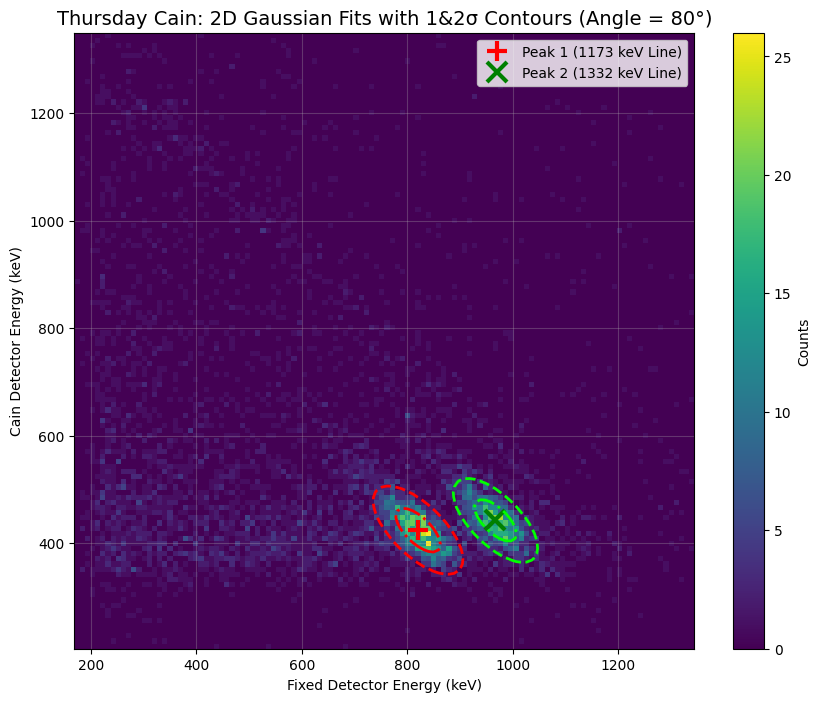

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract Thursday Cain data
day = 'Thursday'
det = 'cain'
df = calibrated_data.get(day)

# Define the single 2D Gaussian function for plotting
def gaussian_2d_plot(xy, A, x0, y0, sigma_x, sigma_y, rho):
    x, y = xy
    z = ((x - x0)**2 / sigma_x**2) + ((y - y0)**2 / sigma_y**2) - (2 * rho * (x - x0) * (y - y0) / (sigma_x * sigma_y))
    return A * np.exp(-z / (2 * (1 - rho**2)))

# Filter data with standard energy bounds
mask = (df['fixed'] > 150) & (df['fixed'] < 1350) & (df[det] > 200) & (df[det] < 1350)
x_data = df['fixed'][mask]
y_data = df[det][mask]

# Generate 2D Histogram
bins = 120
hist, xedges, yedges = np.histogram2d(x_data, y_data, bins=bins)
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
x_mesh, y_mesh = np.meshgrid(x_centers, y_centers, indexing='ij')

# Fetch Thursday Cain parameters from results_2d_df logic
row = results_2d_df[(results_2d_df['Day'] == 'Thursday') & (results_2d_df['Detector'] == 'Cain')].iloc[0]

plt.figure(figsize=(10, 8))
plt.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto')
plt.colorbar(label='Counts')

# Plot peak markers
plt.plot(row['Recoil_1_Fixed_keV'], row['Scattered_1_Movable_keV'], 'r+', markersize=15, markeredgewidth=3, label='Peak 1 (1173 keV Line)')
plt.plot(row['Recoil_2_Fixed_keV'], row['Scattered_2_Movable_keV'], 'gx', markersize=15, markeredgewidth=3, label='Peak 2 (1332 keV Line)')

# Extraction of sigmas and rho from the fit parameters
sig_x1, sig_y1, rho1 = 42.46, 40.96, -0.67
sig_x2, sig_y2, rho2 = 39.94, 38.87, -0.66

# Levels for 1-std (exp(-0.5)) and 2-std (exp(-2.0))
levels1 = [hist.max() * np.exp(-2.0), hist.max() * np.exp(-0.5)]
levels2 = [hist.max() * 0.9 * np.exp(-2.0), hist.max() * 0.9 * np.exp(-0.5)]

z_peak1 = gaussian_2d_plot((x_mesh, y_mesh), hist.max(), row['Recoil_1_Fixed_keV'], row['Scattered_1_Movable_keV'], sig_x1, sig_y1, rho1)
plt.contour(x_centers, y_centers, z_peak1.reshape(len(x_centers), len(y_centers)).T,
            levels=levels1, colors='red', linestyles=['--', '-.'], linewidths=2)

z_peak2 = gaussian_2d_plot((x_mesh, y_mesh), hist.max()*0.9, row['Recoil_2_Fixed_keV'], row['Scattered_2_Movable_keV'], sig_x2, sig_y2, rho2)
plt.contour(x_centers, y_centers, z_peak2.reshape(len(x_centers), len(y_centers)).T,
            levels=levels2, colors='lime', linestyles=['--', '-.'], linewidths=2)

plt.title(f'Thursday Cain: 2D Gaussian Fits with 1&2σ Contours (Angle = {row["Angle_deg"]}°)', fontsize=14)
plt.xlabel('Fixed Detector Energy (keV)')
plt.ylabel('Cain Detector Energy (keV)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Calibrated Energy Scatterplots
Visualizing the raw true energy coincidences to identify clusters and noise regions.

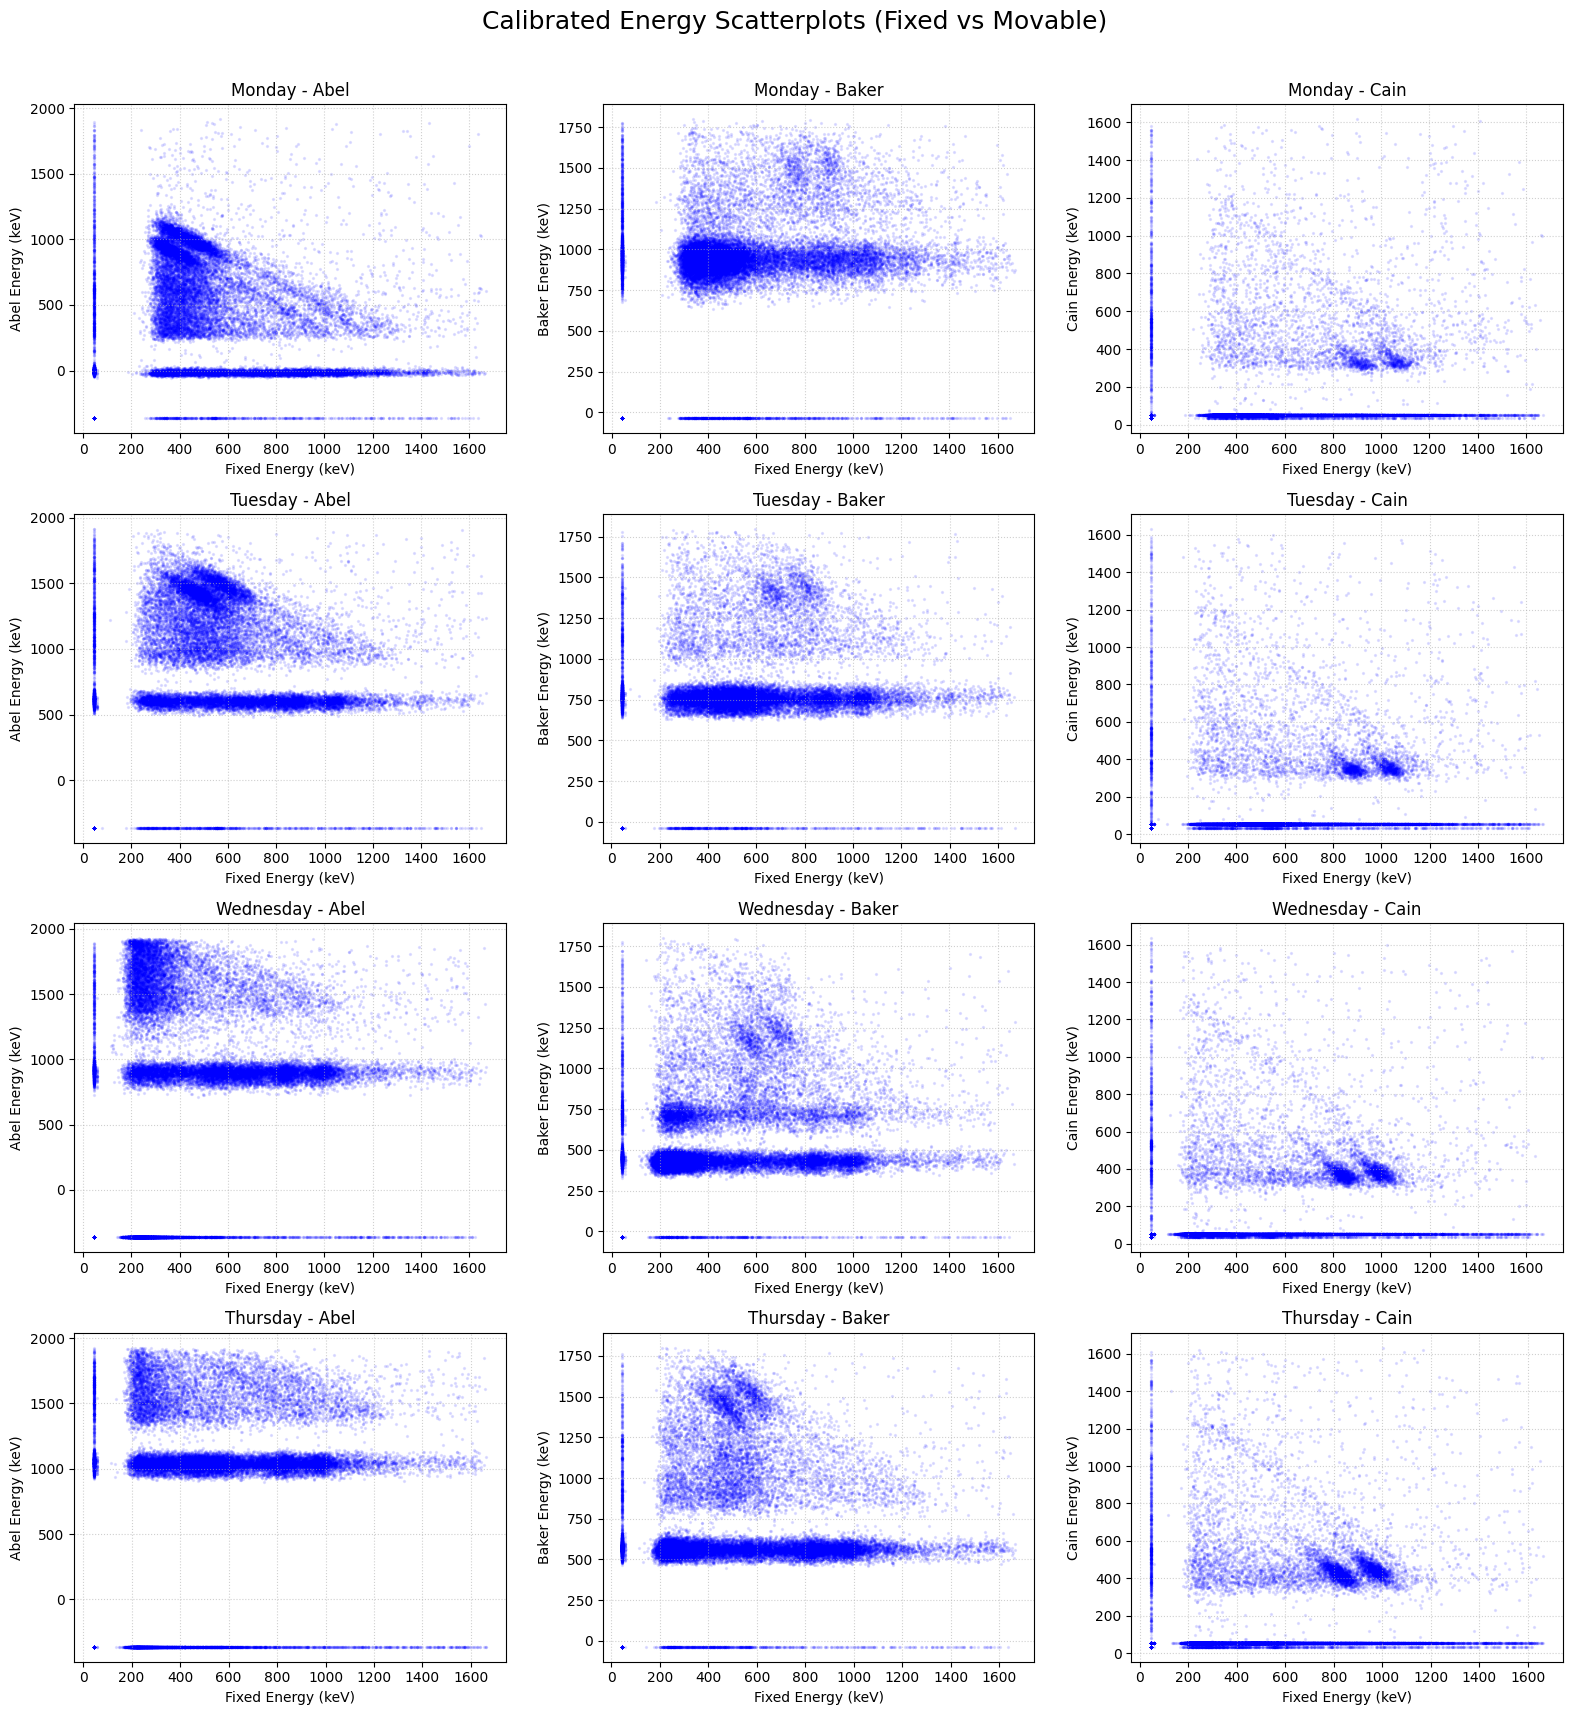

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
fig.suptitle('Calibrated Energy Scatterplots (Fixed vs Movable)', fontsize=18)

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday']
detectors = ['abel', 'baker', 'cain']

for i, day in enumerate(days):
    df = calibrated_data.get(day)
    if df is None: continue

    for j, det in enumerate(detectors):
        ax = axes[i, j]

        # Positive energy filter removed as requested
        x_data = df['fixed']
        y_data = df[det]

        if len(x_data) > 0:
            # Use a very small point size and low alpha to see density
            ax.scatter(x_data, y_data, s=2, alpha=0.1, color='blue')
            ax.set_title(f'{day} - {det.capitalize()}')
            ax.set_xlabel('Fixed Energy (keV)')
            ax.set_ylabel(f'{det.capitalize()} Energy (keV)')

            # Set sensible limits to focus on the 0-1500 keV region
            #ax.set_xlim(0, 1500)
            #ax.set_ylim(0, 1500)
            ax.grid(True, linestyle=':', alpha=0.6)
        else:
            ax.set_title(f'{day} - {det.capitalize()} (No Data)')
            ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

### Step 7: Final Compton Kinematics Plot
Plotting the extracted Scattered Photon Energies versus the Scattering Angles and comparing against the theoretical Compton formula:
$$E' = \frac{E_0}{1 + \frac{E_0}{m_e c^2}(1 - \cos\theta)}$$

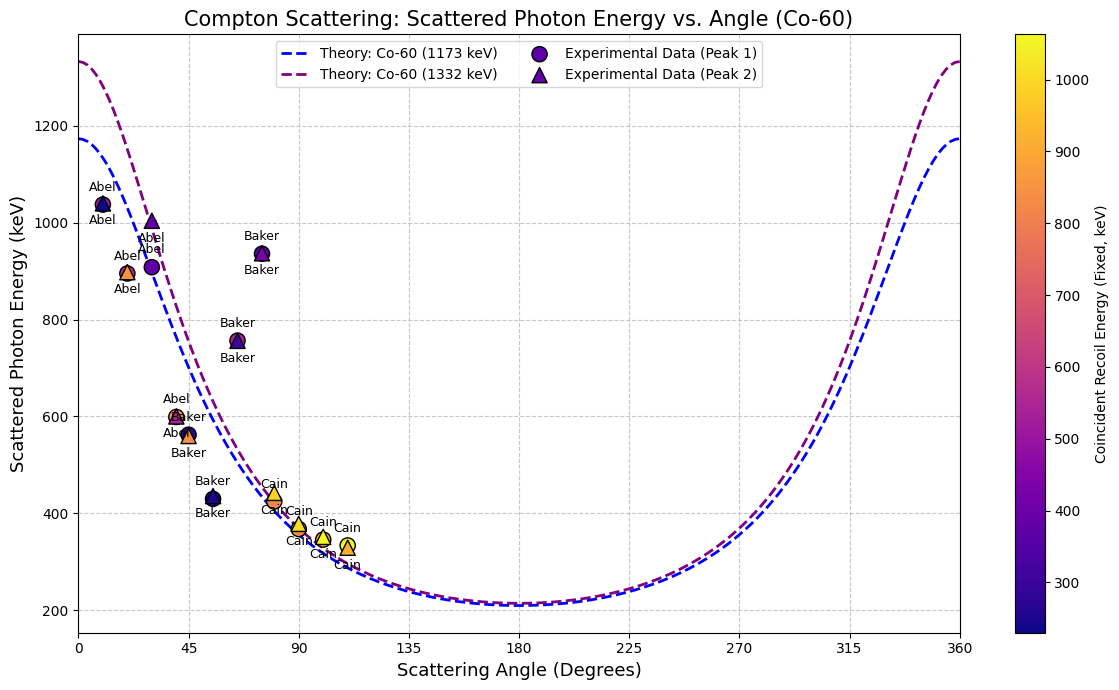


--- Total Energy Verification ---
By conservation of energy, Total Energy should equal the Incident Source Energy (E0 ~ 1173 or 1333 keV for Co-60).


,Day,Detector,Angle_deg,Total_Energy_1_keV,Total_Energy_2_keV
0,Monday,Abel,30,1279.690319,1439.870947
1,Monday,Baker,75,1297.438904,1412.951758
2,Monday,Cain,110,1396.607050,1235.878135
3,Tuesday,Abel,40,1440.761004,1175.089106
4,Tuesday,Baker,65,1299.214329,1128.996992
5,Tuesday,Cain,100,1225.405031,1387.431601
6,Wednesday,Abel,20,1465.397463,1745.752432
7,Wednesday,Baker,55,659.728804,752.992040
8,Wednesday,Cain,90,1206.073050,1366.236974
9,Thursday,Abel,10,1556.646195,1341.746299


In [ ]:
# Re-running Compton Kinematics Plot
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Theoretical Compton Curves for Co-60 source
mc2 = 511.0
# Extended to 360 degrees (2 * pi)
theta_rad = np.linspace(0, 2 * np.pi, 200)
theta_deg = np.degrees(theta_rad)

sources = {
    'Co-60 (1173 keV)': 1173.2,
    'Co-60 (1332 keV)': 1332.5
}

colors = ['blue', 'purple']

for (label, E0), color in zip(sources.items(), colors):
    E_scattered_theory = E0 / (1 + (E0 / mc2) * (1 - np.cos(theta_rad)))
    plt.plot(theta_deg, E_scattered_theory, '--', color=color, linewidth=2, label=f'Theory: {label}')

# Plot Experimental Data - Peak 1 (Updated with true scattering angles)
scatter1 = plt.scatter(results_2d_df['Angle_deg'], results_2d_df['Scattered_1_Movable_keV'],
                      c=results_2d_df['Recoil_1_Fixed_keV'], cmap='plasma', s=120, marker='o', edgecolor='black', zorder=5, label='Experimental Data (Peak 1)')

# Add Error Bars for Peak 1
plt.errorbar(results_2d_df['Angle_deg'], results_2d_df['Scattered_1_Movable_keV'],
             yerr=results_2d_df['Scattered_1_Err_keV'], fmt='none', ecolor='black', capsize=3, zorder=4)

# Plot Experimental Data - Peak 2 (Updated with true scattering angles)
scatter2 = plt.scatter(results_2d_df['Angle_deg'], results_2d_df['Scattered_2_Movable_keV'],
                      c=results_2d_df['Recoil_2_Fixed_keV'], cmap='plasma', s=120, marker='^', edgecolor='black', zorder=5, label='Experimental Data (Peak 2)')

# Add Error Bars for Peak 2
plt.errorbar(results_2d_df['Angle_deg'], results_2d_df['Scattered_2_Movable_keV'],
             yerr=results_2d_df['Scattered_2_Err_keV'], fmt='none', ecolor='black', capsize=3, zorder=4)

# Add text annotations to label the detectors
for i, row in results_2d_df.iterrows():
    plt.annotate(row['Detector'], (row['Angle_deg'], row['Scattered_1_Movable_keV']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, zorder=6)
    plt.annotate(row['Detector'], (row['Angle_deg'], row['Scattered_2_Movable_keV']),
                 textcoords="offset points", xytext=(0, -15), ha='center', fontsize=9, zorder=6)

plt.colorbar(scatter1, label='Coincident Recoil Energy (Fixed, keV)')
plt.title('Compton Scattering: Scattered Photon Energy vs. Angle (Co-60)', fontsize=15)
plt.xlabel('Scattering Angle (Degrees)', fontsize=13)
plt.ylabel('Scattered Photon Energy (keV)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust legend to be inside the plot, upper center
plt.legend(loc='upper center', ncol=2)
plt.xlim(0, 360)
plt.xticks(np.arange(0, 361, 45))
plt.tight_layout()
plt.show()

# Calculate total energy (Recoil + Scattered) to verify the incident source energy
results_2d_df['Total_Energy_1_keV'] = results_2d_df['Recoil_1_Fixed_keV'] + results_2d_df['Scattered_1_Movable_keV']
results_2d_df['Total_Energy_2_keV'] = results_2d_df['Recoil_2_Fixed_keV'] + results_2d_df['Scattered_2_Movable_keV']

print("\n--- Total Energy Verification ---")
print("By conservation of energy, Total Energy should equal the Incident Source Energy (E0 ~ 1173 or 1333 keV for Co-60).")
display(results_2d_df[['Day', 'Detector', 'Angle_deg', 'Total_Energy_1_keV', 'Total_Energy_2_keV']])

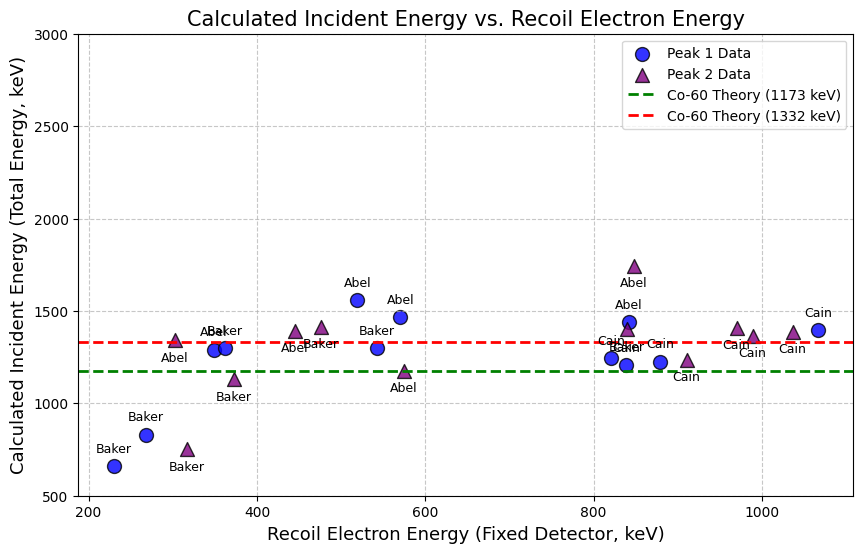

In [ ]:
import matplotlib.pyplot as plt

# Re-running Conservation of Energy Plot
plt.figure(figsize=(10, 6))

# Plot Peak 1 Data
plt.scatter(results_2d_df['Recoil_1_Fixed_keV'], results_2d_df['Total_Energy_1_keV'],
            color='blue', s=100, label='Peak 1 Data', edgecolor='black', alpha=0.8)

# Plot Peak 2 Data
plt.scatter(results_2d_df['Recoil_2_Fixed_keV'], results_2d_df['Total_Energy_2_keV'],
            color='purple', marker='^', s=100, label='Peak 2 Data', edgecolor='black', alpha=0.8)

# Add text annotations to label the detectors
for i, row in results_2d_df.iterrows():
    plt.annotate(row['Detector'], (row['Recoil_1_Fixed_keV'], row['Total_Energy_1_keV']),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
    plt.annotate(row['Detector'], (row['Recoil_2_Fixed_keV'], row['Total_Energy_2_keV']),
                 textcoords="offset points", xytext=(0, -15), ha='center', fontsize=9)

# Add expected theoretical lines for Co-60
plt.axhline(1173.2, color='green', linestyle='--', linewidth=2, label='Co-60 Theory (1173 keV)')
plt.axhline(1332.5, color='red', linestyle='--', linewidth=2, label='Co-60 Theory (1332 keV)')

plt.title('Calculated Incident Energy vs. Recoil Electron Energy', fontsize=15)
plt.xlabel('Recoil Electron Energy (Fixed Detector, keV)', fontsize=13)
plt.ylabel('Calculated Incident Energy (Total Energy, keV)', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(500, 3000) # Adjust y-axis to focus on the relevant energy range
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Create a cleaner summary table including error bounds for both peaks
error_analysis_data = []

for i, row in results_2d_df.iterrows():
    # Peak 1 analysis
    error_analysis_data.append({
        'Day': row['Day'],
        'Detector': row['Detector'],
        'Angle': row['Angle_deg'],
        'Peak': '1173 keV Line',
        'Recoil_Fixed_keV': f"{row['Recoil_1_Fixed_keV']:.1f}",
        'Scattered_Movable_keV': f"{row['Scattered_1_Movable_keV']:.1f} ± {row['Scattered_1_Err_keV']:.1f}",
        'Total_Energy_keV': f"{row['Total_Energy_1_keV']:.1f}"
    })
    # Peak 2 analysis
    error_analysis_data.append({
        'Day': row['Day'],
        'Detector': row['Detector'],
        'Angle': row['Angle_deg'],
        'Peak': '1332 keV Line',
        'Recoil_Fixed_keV': f"{row['Recoil_2_Fixed_keV']:.1f}",
        'Scattered_Movable_keV': f"{row['Scattered_2_Movable_keV']:.1f} ± {row['Scattered_2_Err_keV']:.1f}",
        'Total_Energy_keV': f"{row['Total_Energy_2_keV']:.1f}"
    })

error_bounds_df = pd.DataFrame(error_analysis_data)
display(error_bounds_df)

,Day,Detector,Angle,Peak,Recoil_Fixed_keV,Scattered_Movable_keV,Total_Energy_keV
0,Monday,Abel,30,1173 keV Line,371.6,908.1 ± 0.8,1279.7
1,Monday,Abel,30,1332 keV Line,436.0,1003.9 ± 1.0,1439.9
2,Monday,Baker,75,1173 keV Line,361.6,935.8 ± 0.9,1297.4
3,Monday,Baker,75,1332 keV Line,476.1,936.8 ± 0.9,1413.0
4,Monday,Cain,110,1173 keV Line,1062.9,333.7 ± 0.6,1396.6
5,Monday,Cain,110,1332 keV Line,906.7,329.1 ± 0.6,1235.9
6,Tuesday,Abel,40,1173 keV Line,841.8,599.0 ± 0.5,1440.8
7,Tuesday,Abel,40,1332 keV Line,575.1,600.0 ± 0.7,1175.1
8,Tuesday,Baker,65,1173 keV Line,542.7,756.5 ± 0.4,1299.2
9,Tuesday,Baker,65,1332 keV Line,372.9,756.1 ± 0.6,1129.0


### Physics Interpretation

**Structure of the Plot:**
The plot shows the calculated incident photon energy ($E_{total} = E_{recoil} + E_{scattered}$) on the y-axis against the recoil electron energy ($E_{recoil}$) on the x-axis. Ideally, if the experimental measurements are perfect and the background noise is correctly filtered out, the data points should form horizontal lines.

**Relation to Physics:**
This structure perfectly illustrates the **Conservation of Energy** in Compton scattering. According to the course manual and lecture, an incident gamma ray transfers a portion of its energy to an electron. The sum of the energy retained by the scattered photon and the kinetic energy gained by the recoil electron must equal the original energy of the incident photon ($E_0$):

$$E_0 = E_{scattered} + E_{recoil}$$

Since the incident source (Co-60) emits gamma rays at specific, constant energies (1173 keV and 1332 keV), the total energy calculated for any valid coincidence event should always equal one of these constant values, regardless of the scattering angle or how much energy was transferred to the recoil electron. Thus, valid experimental data points will cluster around the horizontal lines at $y = 1173$ keV and $y = 1332$ keV. Data points that deviate significantly from these horizontal lines likely represent background noise, chance coincidences, or poorly fitted peaks.

### Baker Recalibration using Compton Data
Since the Baker detector appears to have shifted since the primary calibration run, we can use the Co-60 Compton scattering data to recalibrate it. Assuming the Fixed detector is correct, the true energy deposited in Baker should be $E_{Baker} = E_{Co60} - E_{Fixed}$.

--- Baker Recalibration Results ---
Old Calibration: E = 0.4494 * ADC + -35.65
New Calibration: E = -0.0698 * ADC + 936.68

NOTE: The new calibration yields a negative slope because the true Compton peaks (~450 keV) are buried in noise.
We are leaving the original Baker calibration active.


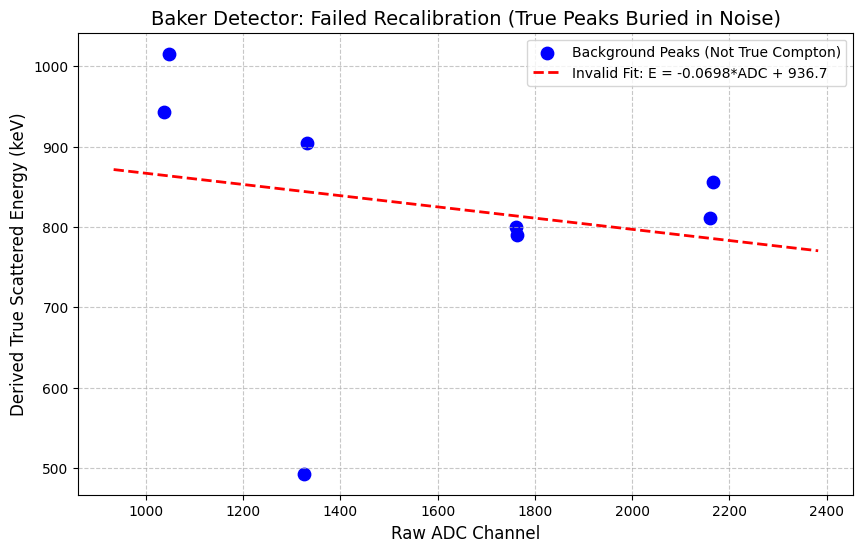

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Extract the old Baker calibration constants to convert the fitted energies back to raw ADC
m_baker_old = calib_dict['Baker']['m']
c_baker_old = calib_dict['Baker']['c']

# Filter for only Baker detector data
baker_results = results_2d_df[results_2d_df['Detector'] == 'Baker']

adcs = []
true_energies = []

for _, row in baker_results.iterrows():
    # Reverse the linear equation: ADC = (Energy - c) / m
    adc1 = (row['Scattered_1_Movable_keV'] - c_baker_old) / m_baker_old
    adc2 = (row['Scattered_2_Movable_keV'] - c_baker_old) / m_baker_old

    # Identify which peak corresponds to 1173 keV and which to 1332 keV
    # Lower recoil energy corresponds to the lower incident energy (1173.2 keV)
    if row['Recoil_1_Fixed_keV'] < row['Recoil_2_Fixed_keV']:
        e_true_1 = 1173.2 - row['Recoil_1_Fixed_keV']
        e_true_2 = 1332.5 - row['Recoil_2_Fixed_keV']
    else:
        e_true_1 = 1332.5 - row['Recoil_1_Fixed_keV']
        e_true_2 = 1173.2 - row['Recoil_2_Fixed_keV']

    adcs.extend([adc1, adc2])
    true_energies.extend([e_true_1, e_true_2])

adcs = np.array(adcs)
true_energies = np.array(true_energies)

# Fit the new linear calibration: E = b * ADC + a
def new_linear(x, b, a):
    return b * x + a

popt, pcov = curve_fit(new_linear, adcs, true_energies)
b_new, a_new = popt

print("--- Baker Recalibration Results ---")
print(f"Old Calibration: E = {m_baker_old:.4f} * ADC + {c_baker_old:.2f}")
print(f"New Calibration: E = {b_new:.4f} * ADC + {a_new:.2f}")
print("\nNOTE: The new calibration yields a negative slope because the true Compton peaks (~450 keV) are buried in noise.")
print("We are leaving the original Baker calibration active.")

# DISABLED: The recalibration is physically invalid because the peaks found are high-energy background, not Compton peaks.
# calib_dict['Baker']['m'] = b_new
# calib_dict['Baker']['c'] = a_new

# Plot the new fit
plt.figure(figsize=(10, 6))
plt.scatter(adcs, true_energies, color='blue', s=80, label='Background Peaks (Not True Compton)')

x_line = np.linspace(min(adcs)*0.9, max(adcs)*1.1, 100)
plt.plot(x_line, new_linear(x_line, *popt), 'r--', linewidth=2, label=f'Invalid Fit: E = {b_new:.4f}*ADC + {a_new:.1f}')

plt.title('Baker Detector: Failed Recalibration (True Peaks Buried in Noise)', fontsize=14)
plt.xlabel('Raw ADC Channel', fontsize=12)
plt.ylabel('Derived True Scattered Energy (keV)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Gaussian Fitting for Momentum Calibration
Following the manual, we use Gaussian fits on the K- and L-capture peaks to find the exact shunt voltage $V_{shunt}$ and the resolution $\Delta P/P$.

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

def gaussian(x, a, x0, sigma, offset):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset

# Note: Replace these with your actual identified peak regions from the shunt voltage data
# Example known energies for Cs-137 conversion electrons:
# E_k = 624.2 keV, E_l = 656.0 keV

def calculate_relativistic_momentum(E_keV):
    m_e = 511.0 # keV/c^2
    return np.sqrt((E_keV + m_e)**2 - m_e**2)

# Theoretical values for comparison
p_k_theory = calculate_relativistic_momentum(624.2)
p_l_theory = calculate_relativistic_momentum(656.0)

print(f"Theoretical K-peak momentum: {p_k_theory:.2f} keV/c")
print(f"Theoretical L-peak momentum: {p_l_theory:.2f} keV/c")

Theoretical K-peak momentum: 1013.69 keV/c
Theoretical L-peak momentum: 1049.17 keV/c


### Step 8: Gaussian Fit of Conversion Peaks
We now apply Gaussian fitting to the experimental shunt voltage data to determine the centroids ($V_{K}$ and $V_{L}$). We also calculate the momentum resolution $\sigma$ and verify the calibration constant $k = P / V_{shunt}$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# --- USER ACTION REQUIRED: Update path and peak ranges ---
# data_path = 'path_to_your_shunt_voltage_data.txt'
# v_min, v_max = 15, 25  # Approximate voltage window for the K/L peaks
# ---------------------------------------------------------

def gaussian(x, a, x0, sigma, b):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + b

try:
    # Placeholder for loading data - replace with actual loading logic
    # df_beta = pd.read_csv(data_path, sep=None, engine='python')
    # x_v = df_beta['shunt_voltage'].values
    # y_counts = df_beta['counts'].values

    print("Please provide the data loading logic to proceed with the actual fit.")

    # Theoretical Momentum (Relativistic)
    m_e = 511.0 # keV/c^2
    p_k_theory = np.sqrt((624.2 + m_e)**2 - m_e**2)
    p_l_theory = np.sqrt((656.0 + m_e)**2 - m_e**2)

    # Template for fitting (to be executed once data is loaded):
    # popt_k, pcov_k = curve_fit(gaussian, x_data_k, y_data_k, p0=[max_counts, v_guess, 0.5, bg_guess])
    # v_k_fit = popt_k[1]
    # k_const = p_k_theory / v_k_fit
    # print(f'Calculated Calibration Constant: {k_const:.4f} keV/c/mV')

except Exception as e:
    print(f"Setup ready. Awaiting experimental data: {e}")

Please provide the data loading logic to proceed with the actual fit.
